## Quick model training (no hyperparameter tuning)

Load data from `dataset/processed`, train XGBoost / LightGBM / CatBoost with default params for early stopping. Use per-market validation split. Scores on train/val/test + predictions on `test_pred.csv`. Useful for testing feature changes and different gaps without running full Optuna tuning.

In [1]:
# Load data from dataset/processed (no cleaning/imputation here)
from data_utils import load_data, get_trainval_with_market, load_real_test, tail_train_val_split
from data_utils import transform_target, inverse_transform_target
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# DATA_DIR = "dataset/processed/subset_1/"
DATA_DIR = "dataset/processed"
VAL_FRAC = 0.2  # per-market validation for early stopping
SEEDS = [19, 26,42, 123, 456]  # train each model with these seeds; use [42] for single seed

# Target transform for skewed distributions: "log1p" (non-negative) | "log_shifted" (handles negatives) | "none"
TARGET_TRANSFORM = None #"log_shifted"

# Feature selection: set by "choose features" cell if run; None = use all features
feat_cols_selected = None

X_train, y_train, X_val, y_val, X_test, y_test, market_train, market_val, market_test = load_data(DATA_DIR, return_market=True)

# Per-market y_min for log_shifted (each market has different price range)
y_min_by_market = None
if TARGET_TRANSFORM == "log_shifted":
    y_min_by_market = {m: float(y_train[market_train == m].min()) for m in np.unique(market_train)}
    y_min = y_min_by_market  # for backwards compat; inv_pred uses y_min_by_market
elif TARGET_TRANSFORM == "log1p":
    y_min = None
else:
    y_min = None

# Transform target per market (y_train, y_val, y_test stay original for metrics)
y_train_t = np.empty(len(y_train))
for m in np.unique(market_train):
    mask = market_train == m
    y_train_t[mask] = transform_target(y_train[mask], TARGET_TRANSFORM, y_min_by_market[m] if y_min_by_market else None)
y_val_t = np.empty(len(y_val))
for m in np.unique(market_val):
    mask = market_val == m
    y_val_t[mask] = transform_target(y_val[mask], TARGET_TRANSFORM, y_min_by_market.get(m, min(y_min_by_market.values())) if y_min_by_market else None)
y_test_t = np.empty(len(y_test))
for m in np.unique(market_test):
    mask = market_test == m
    y_test_t[mask] = transform_target(y_test[mask], TARGET_TRANSFORM, y_min_by_market.get(m, min(y_min_by_market.values())) if y_min_by_market else None)

X_trainval, y_trainval, market_trainval = get_trainval_with_market(X_train, y_train_t, X_val, y_val_t, market_train, market_val)
X_real, ids_real, market_real = load_real_test(DATA_DIR, "test_pred.csv", return_market=True)

def inv_pred(p, markets=None, y_min_override=None):
    """Inverse-transform. If markets given, use per-market y_min. If y_min_override given (single market), use it."""
    if TARGET_TRANSFORM == "none":
        return p
    p = np.asarray(p)
    if y_min_override is not None:
        return inverse_transform_target(p, TARGET_TRANSFORM, y_min_override)
    if markets is not None and y_min_by_market is not None and len(np.unique(markets)) > 0:
        out = np.empty_like(p)
        for m in np.unique(markets):
            mask = np.asarray(markets) == m
            ym = y_min_by_market.get(m, min(y_min_by_market.values()))
            out[mask] = inverse_transform_target(p[mask], TARGET_TRANSFORM, ym)
        return out
    ym = list(y_min_by_market.values())[0] if y_min_by_market else None
    return inverse_transform_target(p, TARGET_TRANSFORM, ym)

def _metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
    }

def _print_scores(name, m):
    print(f"  {name}: MAE={m['mae']:.4f}, RMSE={m['rmse']:.4f}, R2={m['r2']:.4f}")

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
if X_real is not None:
    print(f"Real test (test_pred.csv): {len(X_real)}")
if TARGET_TRANSFORM != "none":
    print(f"Target transform: {TARGET_TRANSFORM}" + (f" (per-market y_min)" if y_min_by_market else ""))

print(f"number of features: {len(X_train.columns)}")

Loaded: train=49428, val=29652, test=19765 (total=98845)
Train: 49428, Val: 29652, Test: 19765
Real test (test_pred.csv): 13098
Target transform: None
number of features: 82


In [2]:
X_train

,global_horizontal_irradiance,diffuse_horizontal_irradiance,direct_normal_irradiance,cloud_cover_total,cloud_cover_low,cloud_cover_mid,cloud_cover_high,precipitation_amount,visibility,air_temperature_2m,...,wind_speed_80m_lag24,wind_speed_80m_lag25,wind_speed_80m_lag168,wind_speed_10m_lag1,wind_speed_10m_lag2,wind_speed_10m_lag3,wind_speed_10m_lag23,wind_speed_10m_lag24,wind_speed_10m_lag25,wind_speed_10m_lag168
0,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,34100.0,15.180500,...,10.787993,18.161278,32.825207,10.440000,9.449572,9.422101,3.758510,5.315336,7.903619,17.114204
1,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,32800.0,14.730500,...,6.151683,10.787993,37.303020,12.758432,10.440000,9.449572,3.096837,3.758510,5.315336,22.596991
2,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,27200.0,14.280500,...,4.320000,6.151683,37.839409,11.620809,12.758432,10.440000,19.406637,3.096837,3.758510,23.400000
3,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,20400.0,13.580501,...,36.179550,4.320000,38.479603,10.245780,11.620809,12.758432,22.864960,19.406637,3.096837,24.967497
4,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,18700.0,13.380500,...,37.107944,36.179550,42.518120,12.371645,10.245780,11.620809,18.875126,22.864960,19.406637,29.686359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49423,0.00,0.00,0.000000,1.0,1.0,0.0,0.0,0.0,15200.0,19.008501,...,2.189795,5.351785,14.693999,9.178235,7.421590,8.404284,6.792466,7.653705,6.696387,5.588703
49424,13.50,4.25,113.207008,2.0,2.0,0.0,0.0,0.0,14500.0,18.858500,...,3.671294,2.189795,20.948164,7.928178,9.178235,7.421590,0.804985,6.792466,7.653705,7.754637
49425,158.25,55.50,506.112183,1.0,1.0,0.0,0.0,0.0,14300.0,21.708500,...,1.938659,3.671294,19.164717,8.280000,7.928178,9.178235,1.484318,0.804985,6.792466,12.074766
49426,385.00,85.25,725.309509,0.0,0.0,0.0,0.0,0.0,21800.0,25.258501,...,2.160000,1.938659,21.313093,5.411986,8.280000,7.928178,1.835647,1.484318,0.804985,16.071491


In [2]:
print(X_train.columns)

# Index(['global_horizontal_irradiance', 'diffuse_horizontal_irradiance',
#        'direct_normal_irradiance', 'cloud_cover_total', 'cloud_cover_low',
#        'cloud_cover_mid', 'cloud_cover_high', 'precipitation_amount',
#        'visibility', 'air_temperature_2m', 'apparent_temperature_2m',
#        'dew_point_temperature_2m', 'wet_bulb_temperature_2m',
#        'surface_pressure', 'freezing_level_height', 'relative_humidity_2m',
#        'convective_available_potential_energy', 'lifted_index',
#        'convective_inhibition', 'wind_speed_80m', 'wind_direction_80m',
#        'wind_gust_speed_10m', 'wind_speed_10m', 'solar_forecast',
#        'wind_forecast', 'load_forecast', 'hour', 'dow', 'month', 'weekofyear',
#        'quarter', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
#        'wind_u_80', 'wind_v_80', 'pressure_normalized', 'renewable_frac',
#        'load_forecast_lag1', 'load_forecast_lag2', 'load_forecast_lag3',
#        'load_forecast_lag23', 'load_forecast_lag24', 'load_forecast_lag25',
#        'load_forecast_lag168', 'solar_forecast_lag1', 'solar_forecast_lag2',
#        'solar_forecast_lag3', 'solar_forecast_lag23', 'solar_forecast_lag24',
#        'solar_forecast_lag25', 'solar_forecast_lag168', 'wind_forecast_lag1',
#        'wind_forecast_lag2', 'wind_forecast_lag3', 'wind_forecast_lag23',
#        'wind_forecast_lag24', 'wind_forecast_lag25', 'wind_forecast_lag168',
#        'air_temperature_2m_lag1', 'air_temperature_2m_lag2',
#        'air_temperature_2m_lag3', 'air_temperature_2m_lag23',
#        'air_temperature_2m_lag24', 'air_temperature_2m_lag25',
#        'air_temperature_2m_lag168', 'wind_speed_80m_lag1',
#        'wind_speed_80m_lag2', 'wind_speed_80m_lag3', 'wind_speed_80m_lag23',
#        'wind_speed_80m_lag24', 'wind_speed_80m_lag25', 'wind_speed_80m_lag168',
#        'wind_speed_10m_lag1', 'wind_speed_10m_lag2', 'wind_speed_10m_lag3',
#        'wind_speed_10m_lag23', 'wind_speed_10m_lag24', 'wind_speed_10m_lag25',
#        'wind_speed_10m_lag168'],
#       dtype='object') #best score features

Index(['global_horizontal_irradiance', 'diffuse_horizontal_irradiance',
       'direct_normal_irradiance', 'cloud_cover_total', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_high', 'precipitation_amount',
       'visibility', 'air_temperature_2m', 'apparent_temperature_2m',
       'dew_point_temperature_2m', 'wet_bulb_temperature_2m',
       'surface_pressure', 'freezing_level_height', 'relative_humidity_2m',
       'convective_available_potential_energy', 'lifted_index',
       'convective_inhibition', 'wind_speed_80m', 'wind_direction_80m',
       'wind_gust_speed_10m', 'wind_speed_10m', 'solar_forecast',
       'wind_forecast', 'load_forecast', 'hour', 'dow', 'month', 'weekofyear',
       'quarter', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'wind_u_80', 'wind_v_80', 'pressure_normalized', 'renewable_frac',
       'load_forecast_lag1', 'load_forecast_lag2', 'load_forecast_lag3',
       'load_forecast_lag23', 'load_forecast_lag24', 'load_forecast_l

In [ ]:
# XGBoost (light, no tuning) — train with multiple seeds
import xgboost as xgb

xgb_preds_by_seed = {}  # {seed: (train, val, test, real)}
for seed in SEEDS:
    X_tr, y_tr, X_va, y_va = tail_train_val_split(X_trainval, y_trainval, val_frac=VAL_FRAC, market=market_trainval)
    params = {
        "objective": "reg:squarederror",  # RMSE objective
        "eval_metric": "rmse",
        # "objective": "reg:absoluteerror",  # MAE objective
        # "eval_metric": "mae",
        "tree_method": "hist", "max_depth": 6, "eta": 0.05,
        "subsample": 0.8, "colsample_bytree": 0.8, "seed": seed,
    }
    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval = xgb.DMatrix(X_va, label=y_va)
    bst = xgb.train(params, dtrain, num_boost_round=2000, evals=[(dval, "val")],
                    early_stopping_rounds=150, verbose_eval=False)
    p_train = bst.predict(xgb.DMatrix(X_train))
    p_val = bst.predict(xgb.DMatrix(X_val))
    p_test = bst.predict(xgb.DMatrix(X_test))
    p_real = bst.predict(xgb.DMatrix(X_real)) if X_real is not None else None
    xgb_preds_by_seed[seed] = (p_train, p_val, p_test, p_real)

# Averaged predictions (across seeds), inverse-transform to original scale (per-market y_min)
xgb_pred_train = inv_pred(np.mean([xgb_preds_by_seed[s][0] for s in SEEDS], axis=0), market_train)
xgb_pred_val   = inv_pred(np.mean([xgb_preds_by_seed[s][1] for s in SEEDS], axis=0), market_val)
xgb_pred_test  = inv_pred(np.mean([xgb_preds_by_seed[s][2] for s in SEEDS], axis=0), market_test)
xgb_pred_real  = inv_pred(np.mean([xgb_preds_by_seed[s][3] for s in SEEDS], axis=0), market_real) if X_real is not None else None

print("XGBoost scores (averaged over seeds", SEEDS, "):")
_print_scores("Train", _metrics(y_train, xgb_pred_train))
_print_scores("Val",   _metrics(y_val, xgb_pred_val))
_print_scores("Test",  _metrics(y_test, xgb_pred_test))
if X_real is not None:
    print(f"\nPredictions on test_pred.csv: {len(xgb_pred_real)} rows")
if xgb_pred_real is not None:
    plt.hist(xgb_pred_real)
    plt.tight_layout(); plt.show()


In [ ]:
# LightGBM (light, no tuning) — train with multiple seeds
import lightgbm as lgb

lgb_preds_by_seed = {}  # {seed: (train, val, test, real)}
for seed in SEEDS:
    X_tr, y_tr, X_va, y_va = tail_train_val_split(X_trainval, y_trainval, val_frac=VAL_FRAC, market=market_trainval)
    params = {
        "objective": "regression", "metric": "rmse",  # RMSE/L2
        # "objective": "regression_l1", "metric": "mae",  # MAE
        "num_leaves": 63, "learning_rate": 0.05, "max_depth": 6,
        "subsample": 0.8, "colsample_bytree": 0.8, "random_state": seed, "verbosity": -1,
    }
    model = lgb.LGBMRegressor(**params, n_estimators=2000)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(150, verbose=False)])
    p_train = model.predict(X_train)
    p_val = model.predict(X_val)
    p_test = model.predict(X_test)
    p_real = model.predict(X_real) if X_real is not None else None
    lgb_preds_by_seed[seed] = (p_train, p_val, p_test, p_real)

# Averaged predictions (across seeds), inverse-transform to original scale (per-market y_min)
lgb_pred_train = inv_pred(np.mean([lgb_preds_by_seed[s][0] for s in SEEDS], axis=0), market_train)
lgb_pred_val   = inv_pred(np.mean([lgb_preds_by_seed[s][1] for s in SEEDS], axis=0), market_val)
lgb_pred_test  = inv_pred(np.mean([lgb_preds_by_seed[s][2] for s in SEEDS], axis=0), market_test)
lgb_pred_real  = inv_pred(np.mean([lgb_preds_by_seed[s][3] for s in SEEDS], axis=0), market_real) if X_real is not None else None

print("LightGBM scores (averaged over seeds", SEEDS, "):")
_print_scores("Train", _metrics(y_train, lgb_pred_train))
_print_scores("Val",   _metrics(y_val, lgb_pred_val))
_print_scores("Test",  _metrics(y_test, lgb_pred_test))
if X_real is not None:
    print(f"\nPredictions on test_pred.csv: {len(lgb_pred_real)} rows")
if lgb_pred_real is not None:
    plt.hist(lgb_pred_real)
    plt.tight_layout(); plt.show()

In [ ]:
# CatBoost (light, no tuning) — train with multiple seeds
import catboost as cb

cb_preds_by_seed = {}  # {seed: (train, val, test, real)}
for seed in SEEDS:
    X_tr, y_tr, X_va, y_va = tail_train_val_split(X_trainval, y_trainval, val_frac=VAL_FRAC, market=market_trainval)
    params = {
        "loss_function": "RMSE", "iterations": 2000, "learning_rate": 0.05,
        # "loss_function": "MAE",
        "depth": 6, "subsample": 0.8, "rsm": 0.8, "random_seed": seed, "verbose": False,
    }
    model = cb.CatBoostRegressor(**params)
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True, early_stopping_rounds=150)
    p_train = model.predict(X_train)
    p_val = model.predict(X_val)
    p_test = model.predict(X_test)
    p_real = model.predict(X_real) if X_real is not None else None
    cb_preds_by_seed[seed] = (p_train, p_val, p_test, p_real)

# Averaged predictions (across seeds), inverse-transform to original scale (per-market y_min)
cb_pred_train = inv_pred(np.mean([cb_preds_by_seed[s][0] for s in SEEDS], axis=0), market_train)
cb_pred_val   = inv_pred(np.mean([cb_preds_by_seed[s][1] for s in SEEDS], axis=0), market_val)
cb_pred_test  = inv_pred(np.mean([cb_preds_by_seed[s][2] for s in SEEDS], axis=0), market_test)
cb_pred_real  = inv_pred(np.mean([cb_preds_by_seed[s][3] for s in SEEDS], axis=0), market_real) if X_real is not None else None

print("CatBoost scores (averaged over seeds", SEEDS, "):")
_print_scores("Train", _metrics(y_train, cb_pred_train))
_print_scores("Val",   _metrics(y_val, cb_pred_val))
_print_scores("Test",  _metrics(y_test, cb_pred_test))
if X_real is not None:
    print(f"\nPredictions on test_pred.csv: {len(cb_pred_real)} rows")
if cb_pred_real is not None:
    plt.hist(cb_pred_real)
    plt.tight_layout(); plt.show()

In [ ]:
# XGBoost with custom combined MAE+RMSE objective (multi-seed)
import xgboost as xgb

def xgb_combined_obj(preds, dtrain):
    """Custom objective: 0.5*MSE + 0.5*MAE. Returns (grad, hess)."""
    labels = dtrain.get_label()
    diff = preds - labels
    grad = diff + 0.5 * np.sign(diff)
    hess = np.ones_like(preds)
    return grad, hess

xgb_multi_preds_by_seed = {}
for seed in SEEDS:
    X_tr, y_tr, X_va, y_va = tail_train_val_split(X_trainval, y_trainval, val_frac=VAL_FRAC, market=market_trainval)
    params = {
        "eval_metric": "rmse",
        "tree_method": "hist", "max_depth": 6, "eta": 0.05,
        "subsample": 0.8, "colsample_bytree": 0.8, "seed": seed,
    }
    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval = xgb.DMatrix(X_va, label=y_va)
    bst = xgb.train(params, dtrain, num_boost_round=2000, evals=[(dval, "val")],
                    early_stopping_rounds=150, verbose_eval=False,
                    obj=xgb_combined_obj)
    p_train = bst.predict(xgb.DMatrix(X_train))
    p_val = bst.predict(xgb.DMatrix(X_val))
    p_test = bst.predict(xgb.DMatrix(X_test))
    p_real = bst.predict(xgb.DMatrix(X_real)) if X_real is not None else None
    xgb_multi_preds_by_seed[seed] = (p_train, p_val, p_test, p_real)

xgb_multi_pred_train = inv_pred(np.mean([xgb_multi_preds_by_seed[s][0] for s in SEEDS], axis=0), market_train)
xgb_multi_pred_val   = inv_pred(np.mean([xgb_multi_preds_by_seed[s][1] for s in SEEDS], axis=0), market_val)
xgb_multi_pred_test  = inv_pred(np.mean([xgb_multi_preds_by_seed[s][2] for s in SEEDS], axis=0), market_test)
xgb_multi_pred_real  = inv_pred(np.mean([xgb_multi_preds_by_seed[s][3] for s in SEEDS], axis=0), market_real) if X_real is not None else None

print("XGBoost (custom MAE+RMSE) scores (averaged over seeds", SEEDS, "):")
_print_scores("Train", _metrics(y_train, xgb_multi_pred_train))
_print_scores("Val",   _metrics(y_val, xgb_multi_pred_val))
_print_scores("Test",  _metrics(y_test, xgb_multi_pred_test))
if X_real is not None:
    print(f"\nPredictions on test_pred.csv: {len(xgb_multi_pred_real)} rows")
    plt.hist(xgb_multi_pred_real)
    plt.tight_layout()
    plt.show()




In [ ]:
# LightGBM with custom combined MAE+RMSE objective (multi-seed)
# Pass custom objective in params["objective"] (LightGBM 4.x uses objective, not fobj)
import lightgbm as lgb

def lgb_combined_obj(preds, train_data):
    """Custom objective: 0.5*MSE + 0.5*MAE. Returns (grad, hess)."""
    labels = train_data.get_label()
    diff = preds - labels
    grad = diff + 0.5 * np.sign(diff)
    hess = np.ones_like(preds)
    return grad, hess

lgb_multi_preds_by_seed = {}
for seed in SEEDS:
    X_tr, y_tr, X_va, y_va = tail_train_val_split(X_trainval, y_trainval, val_frac=VAL_FRAC, market=market_trainval)
    params = {
        "objective": lgb_combined_obj,
        "metric": "rmse",
        "num_leaves": 63, "learning_rate": 0.05, "max_depth": 6,
        "subsample": 0.8, "colsample_bytree": 0.8, "random_state": seed, "verbosity": -1,
    }
    train_set = lgb.Dataset(X_tr, label=y_tr)
    val_set = lgb.Dataset(X_va, label=y_va, reference=train_set)
    bst = lgb.train(
        params, train_set, num_boost_round=2000,
        valid_sets=[val_set], valid_names=["val"],
        callbacks=[lgb.early_stopping(150, verbose=False)],
    )
    p_train = bst.predict(X_train)
    p_val = bst.predict(X_val)
    p_test = bst.predict(X_test)
    p_real = bst.predict(X_real) if X_real is not None else None
    lgb_multi_preds_by_seed[seed] = (p_train, p_val, p_test, p_real)

lgb_multi_pred_train = inv_pred(np.mean([lgb_multi_preds_by_seed[s][0] for s in SEEDS], axis=0), market_train)
lgb_multi_pred_val   = inv_pred(np.mean([lgb_multi_preds_by_seed[s][1] for s in SEEDS], axis=0), market_val)
lgb_multi_pred_test  = inv_pred(np.mean([lgb_multi_preds_by_seed[s][2] for s in SEEDS], axis=0), market_test)
lgb_multi_pred_real  = inv_pred(np.mean([lgb_multi_preds_by_seed[s][3] for s in SEEDS], axis=0), market_real) if X_real is not None else None

print("LightGBM (custom MAE+RMSE) scores (averaged over seeds", SEEDS, "):")
_print_scores("Train", _metrics(y_train, lgb_multi_pred_train))
_print_scores("Val",   _metrics(y_val, lgb_multi_pred_val))
_print_scores("Test",  _metrics(y_test, lgb_multi_pred_test))
if X_real is not None:
    print(f"\nPredictions on test_pred.csv: {len(lgb_multi_pred_real)} rows")
    plt.hist(lgb_multi_pred_real)
    plt.tight_layout()
    plt.show()


In [ ]:
# Ensemble: average predictions from XGBoost, LightGBM, CatBoost
import pandas as pd

ens_pred_train = (xgb_pred_train + lgb_pred_train + cb_pred_train) / 3
ens_pred_val = (xgb_pred_val + lgb_pred_val + cb_pred_val) / 3
ens_pred_test = (xgb_pred_test + lgb_pred_test + cb_pred_test) / 3

# ens_pred_train = (xgb_multi_pred_train + lgb_multi_pred_train) / 2
# ens_pred_val = (xgb_multi_pred_val + lgb_multi_pred_val) / 2
# ens_pred_test = (xgb_multi_pred_test + lgb_multi_pred_test) / 2

print("Ensemble (mean) scores:")
_print_scores("Train", _metrics(y_train, ens_pred_train))
_print_scores("Val",   _metrics(y_val, ens_pred_val))
_print_scores("Test",  _metrics(y_test, ens_pred_test))




if X_real is not None:
    ens_pred_real = (xgb_pred_real + lgb_pred_real + cb_pred_real) / 3
    # ens_pred_real = (xgb_multi_pred_real + lgb_multi_pred_real) / 2
    # ens_pred_real = cb_pred_real
    sub = pd.DataFrame({"id": ids_real.values, "target": ens_pred_real})
    # sub.to_csv("submissions/submission_ensemble_mean.csv", index=False)
    # print(f"\nSubmission saved: submissions/submission_ensemble_mean.csv ({len(sub)} rows)")

# ── Write submission files ─────────────────────────────────────────────────────
sample_sub = pd.read_csv("submissions/sample_submission_targets.csv")
def save_sub(sub, fname):
    # sub = pd.DataFrame({"id": X_test_pred["id"], "target": preds})
    # Check format
    assert list(sub.columns) == ['id', 'target'], "Wrong columns!"
    assert len(sub) == 13098, f"Wrong row count: {len(sub)}"
    assert sub['id'].min() == 133627, "IDs must start at 133627"
    assert sub['id'].max() == 146778, "IDs must end at 146778"
    assert sub['target'].notna().all(), "No NaN values allowed!"
    assert np.isfinite(sub['target']).all(), "No infinite values allowed!"
    print("✅ Validation passed!")

    sub.to_csv(f"submissions/{fname}", index=False)
    print(f"Saved {fname}  ({len(sub)} rows)")

# save_sub(sub, "submission_ensemble_mean_multi_objective_multi_seeds_20pct_3.csv")
# save_sub(sub, "submission_ensemble_mean_rmse_multi_seeds_20pct_3.csv")

plt.hist(ens_pred_real)
plt.tight_layout()
plt.show()

In [6]:
print(f"max: {np.max(ens_pred_real)}")
print(f"min: {np.min(ens_pred_real)}")
print(f"mean: {np.mean(ens_pred_real)}")
print(f"std: {np.std(ens_pred_real)}")
print(f"median: {np.median(ens_pred_real)}")

max: 280.5192603509733
min: -2.944784255231474
mean: 24.87864762604854
std: 16.557845414791135
median: 21.169986021999666


## Per-market models

Train a **separate model per market** (XGBoost, LightGBM, CatBoost), using all features, per-market tail validation split, and multi-seed averaging. Then predict with the corresponding model for each market. Use when errors are concentrated in specific markets (e.g. Market A).

**Requires:** Load data cell and imports from above. Run data loading cell first.

Top 20 features (avg importance across XGB/LGB/CB, normalized):


,feature,xgb_gain,lgb_split,cb_importance,xgb_gain_pct,lgb_split_pct,cb_importance_pct,avg_pct
0,renewable_frac,115797.127604,63.666667,16.408054,53.130205,100.000000,100.000000,84.376735
1,pressure_normalized,147131.331380,35.666667,5.325524,67.507010,56.020942,32.456769,51.994907
2,air_temperature_2m,217949.709635,11.000000,5.972836,100.000000,17.277487,36.401856,51.226448
3,air_temperature_2m_lag1,189047.854818,15.000000,6.558128,86.739209,23.560209,39.968960,50.089460
4,wind_v_80,165257.168294,19.333333,7.111224,75.823532,30.366492,43.339842,49.843289
5,air_temperature_2m_ma48,102542.963867,25.833333,5.090781,47.048911,40.575916,31.026113,39.550313
6,surface_pressure,152671.909505,6.166667,5.236059,70.049146,9.685864,31.911519,37.215510
7,solar_forecast_ma24,51349.396810,39.000000,1.359856,23.560204,61.256545,8.287738,31.034829
8,air_temperature_2m_lag2,98103.208333,13.666667,4.237787,45.011855,21.465969,25.827482,30.768435
9,wind_speed_80m,79917.758464,22.500000,3.311180,36.667981,35.340314,20.180215,30.729503


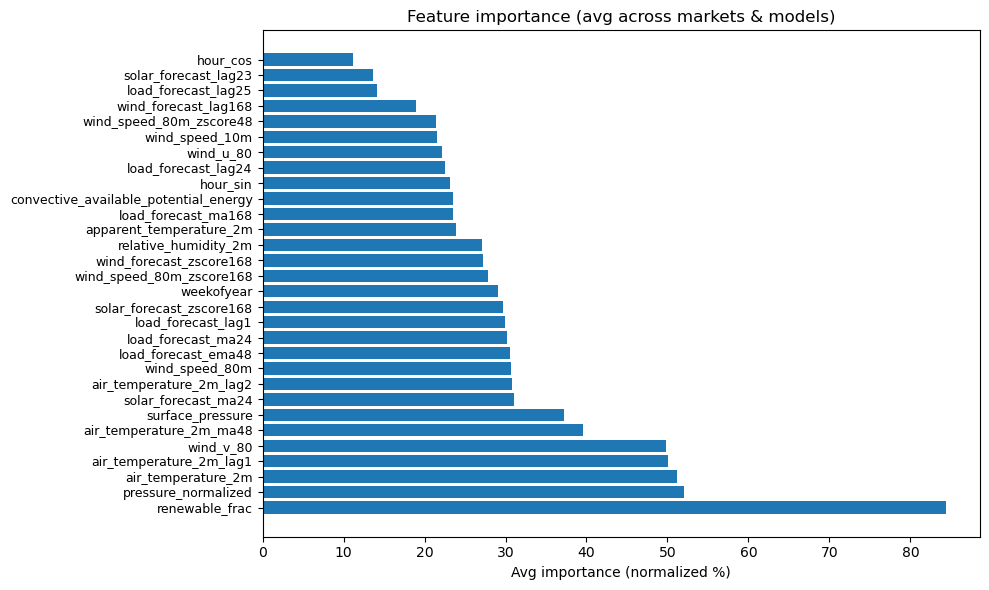

In [46]:
# Feature importance from per-market boosting models
# Extracts importance from models_xgb, models_lgb, models_cb and shows average across markets

import pandas as pd

def get_xgb_importance(bst, feat_cols):
    """XGB Booster returns {'f0': gain, ...} or {feature_name: gain} — map to feat_cols."""
    score = bst.get_score(importance_type='gain')
    feat_to_idx = {str(f): i for i, f in enumerate(feat_cols)}
    imp = [0.0] * len(feat_cols)
    for k, v in score.items():
        if k in feat_to_idx:
            imp[feat_to_idx[k]] = float(v)
        elif k.startswith('f') and k[1:].isdigit():
            idx = int(k[1:])
            if idx < len(feat_cols):
                imp[idx] = float(v)
    return imp

def get_lgb_importance(m):
    return m.feature_importances_.tolist()

def get_cb_importance(m):
    return m.get_feature_importance().tolist()

# Aggregate importance across all markets (mean)
imp_xgb = np.mean([get_xgb_importance(models_xgb[m], feat_cols) for m in markets], axis=0)
imp_lgb = np.mean([get_lgb_importance(models_lgb[m]) for m in markets], axis=0)
imp_cb = np.mean([get_cb_importance(models_cb[m]) for m in markets], axis=0)

# Build DataFrame
df_imp = pd.DataFrame({
    'feature': feat_cols,
    'xgb_gain': imp_xgb,
    'lgb_split': imp_lgb,
    'cb_importance': imp_cb,
})
# Normalize each column to 0-100 for comparison
for c in ['xgb_gain', 'lgb_split', 'cb_importance']:
    mx = df_imp[c].max()
    if mx > 0:
        df_imp[c + '_pct'] = 100 * df_imp[c] / mx
    else:
        df_imp[c + '_pct'] = 0
df_imp['avg_pct'] = (df_imp['xgb_gain_pct'] + df_imp['lgb_split_pct'] + df_imp['cb_importance_pct']) / 3
df_imp = df_imp.sort_values('avg_pct', ascending=False).reset_index(drop=True)

# Top 20 features
print("Top 20 features (avg importance across XGB/LGB/CB, normalized):")
display(df_imp.head(60))

# Bar plot: top 15 features
top_n = min(50, len(df_imp))
top_df = df_imp.head(top_n).iloc[::-1]  # reverse so highest at top
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(top_n)
ax.barh(y_pos, top_df['avg_pct'].values)
ax.set_yticks(y_pos)
ax.set_yticklabels([str(f) for f in top_df['feature'].values], fontsize=9)
ax.set_xlabel('Avg importance (normalized %)')
ax.set_title('Feature importance (avg across markets & models)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [38]:
# Choose features for training: select top N by avg_pct from df_imp. Run AFTER feature importance cell.
# If you DON'T run this cell, feat_cols_selected stays None and per-market uses all features.
# Set TOP_N = None or 0 to reset to all features (clears selection).

TOP_N = 30  # top N features by avg_pct; set None or 0 to use all features

if TOP_N is None or TOP_N <= 0:
    feat_cols_selected = None
    print("feat_cols_selected = None (using all features)")
else:
    feat_cols_selected = df_imp.head(TOP_N)["feature"].tolist()
    print(f"Selected top {TOP_N} features. Re-run per-market cell to train with these.")
    print(f"Features: {feat_cols_selected[:5]}..." if len(feat_cols_selected) > 5 else f"Features: {feat_cols_selected}")

Selected top 30 features. Re-run per-market cell to train with these.
Features: ['renewable_frac', 'wind_v_80', 'load_forecast_ema48', 'air_temperature_2m', 'air_temperature_2m_ma48']...


In [3]:
# Per-market training: one model per market, multi-seed average, all features
# Uses same VAL_FRAC, SEEDS as above. Predicts with corresponding model per market.
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

EXCLUDED = ["Unnamed: 1", "id", "delivery_start", "delivery_end", "target", "is_test", "is_val", "market", "market.1"]
EMBARGO = 168  # drop first 168 rows per market from val/test (max lag/rolling window)

train_full = pd.read_csv(f"{DATA_DIR}/train.csv")
val_full = pd.read_csv(f"{DATA_DIR}/val.csv")
test_full = pd.read_csv(f"{DATA_DIR}/test.csv")
test_pred_full = pd.read_csv(f"{DATA_DIR}/test_pred.csv")
feat_cols_all = [c for c in train_full.columns if c not in EXCLUDED]
# Use feat_cols_selected (from "choose features" cell) if set; else use all features
feat_cols = feat_cols_selected if feat_cols_selected is not None else feat_cols_all
print(f"Using {len(feat_cols)} features" + (f" (top {len(feat_cols)} by importance)" if feat_cols_selected is not None else " (all)"))

markets = sorted(train_full["market"].unique())
models_xgb, models_lgb, models_cb = {}, {}, {}
y_min_per_market = {}
per_mkt_scores = []
all_y_tr, all_y_va, all_y_te = [], [], []
all_p_tr, all_p_va, all_p_te = [], [], []

def _m(y, p):
    return {"mae": mean_absolute_error(y, p), "rmse": np.sqrt(mean_squared_error(y, p)), "r2": r2_score(y, p)}

# Parse delivery_start for chronological sorting
train_full["delivery_start"] = pd.to_datetime(train_full["delivery_start"])
val_full["delivery_start"] = pd.to_datetime(val_full["delivery_start"])
test_full["delivery_start"] = pd.to_datetime(test_full["delivery_start"])

for mkt in markets:
    tr = train_full[train_full["market"] == mkt].copy()
    va = val_full[val_full["market"] == mkt].copy()
    te = test_full[test_full["market"] == mkt].copy()
    tr = pd.concat([tr, va], ignore_index=True).sort_values("delivery_start").reset_index(drop=True)

    X_m = tr[feat_cols]
    y_m = tr["target"]
    n = len(X_m)
    cut = int(np.floor((1 - VAL_FRAC) * n))
    X_tr, y_tr = X_m.iloc[:cut], y_m.iloc[:cut]
    X_va, y_va = X_m.iloc[cut:], y_m.iloc[cut:]
    X_te = te[feat_cols]
    y_te = te["target"]

    # Per-market y_min (from this market's training data)
    y_min_m = float(y_tr.min()) if TARGET_TRANSFORM == "log_shifted" else None
    if y_min_m is not None:
        y_min_per_market[mkt] = y_min_m
    y_tr_t = transform_target(y_tr.values, TARGET_TRANSFORM, y_min_m)
    y_va_t = transform_target(y_va.values, TARGET_TRANSFORM, y_min_m)

    # Embargo: drop first EMBARGO rows (lag/rolling features need warm-up, avoid split contamination)
    if len(X_va) > EMBARGO:
        X_va = X_va.iloc[EMBARGO:].reset_index(drop=True)
        y_va = y_va.iloc[EMBARGO:].reset_index(drop=True)
        y_va_t = y_va_t[EMBARGO:]
    if len(X_te) > EMBARGO:
        X_te = X_te.iloc[EMBARGO:].reset_index(drop=True)
        y_te = y_te.iloc[EMBARGO:].reset_index(drop=True)

    preds_xgb, preds_lgb, preds_cb = [], [], []
    preds_xgb_tr, preds_lgb_tr, preds_cb_tr = [], [], []
    preds_xgb_va, preds_lgb_va, preds_cb_va = [], [], []
    for seed in SEEDS:
        # XGBoost
        dtrain = xgb.DMatrix(X_tr, label=y_tr_t)
        dval = xgb.DMatrix(X_va, label=y_va_t)
        bst = xgb.train({"objective": "reg:squarederror", "eval_metric": "rmse", "tree_method": "hist", "max_depth": 6, "eta": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "seed": seed}, dtrain, num_boost_round=2000, evals=[(dval, "val")], early_stopping_rounds=150, verbose_eval=False)
        preds_xgb_tr.append(bst.predict(xgb.DMatrix(X_tr)))
        preds_xgb_va.append(bst.predict(xgb.DMatrix(X_va)))
        preds_xgb.append(bst.predict(xgb.DMatrix(X_te)))
        # LightGBM
        m = lgb.LGBMRegressor(objective="regression", metric="rmse", num_leaves=63, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=seed, n_estimators=2000, verbosity=-1)
        m.fit(X_tr, y_tr_t, eval_set=[(X_va, y_va_t)], callbacks=[lgb.early_stopping(150, verbose=False)])
        preds_lgb_tr.append(m.predict(X_tr))
        preds_lgb_va.append(m.predict(X_va))
        preds_lgb.append(m.predict(X_te))
        # CatBoost
        m2 = cb.CatBoostRegressor(loss_function="RMSE", iterations=2000, learning_rate=0.05, depth=6, subsample=0.8, rsm=0.8, random_seed=seed, verbose=False)
        m2.fit(X_tr, y_tr_t, eval_set=(X_va, y_va_t), use_best_model=True, early_stopping_rounds=150)
        preds_cb_tr.append(m2.predict(X_tr))
        preds_cb_va.append(m2.predict(X_va))
        preds_cb.append(m2.predict(X_te))

    p_tr = inv_pred((np.mean(preds_xgb_tr, axis=0) + np.mean(preds_lgb_tr, axis=0) + np.mean(preds_cb_tr, axis=0)) / 3, y_min_override=y_min_m)
    p_va = inv_pred((np.mean(preds_xgb_va, axis=0) + np.mean(preds_lgb_va, axis=0) + np.mean(preds_cb_va, axis=0)) / 3, y_min_override=y_min_m)
    p_xgb = np.mean(preds_xgb, axis=0)
    p_lgb = np.mean(preds_lgb, axis=0)
    p_cb = np.mean(preds_cb, axis=0)
    p_ens = inv_pred((p_xgb + p_lgb + p_cb) / 3, y_min_override=y_min_m)


    all_y_tr.append(y_tr.values)
    all_y_va.append(y_va.values)
    all_y_te.append(y_te.values)
    all_p_tr.append(p_tr)
    all_p_va.append(p_va)
    all_p_te.append(p_ens)

    metrics_tr = _m(y_tr, p_tr)
    metrics_va = _m(y_va, p_va)
    metrics_te = _m(y_te, p_ens)
    per_mkt_scores.append({"market": mkt, "n_train": len(y_tr), "n_val": len(y_va), "n_test": len(y_te),
                          "train": metrics_tr, "val": metrics_va, "test": metrics_te})
    models_xgb[mkt] = bst
    models_lgb[mkt] = m
    models_cb[mkt] = m2

# Overall metrics (pooled across all markets)
y_tr_all = np.concatenate(all_y_tr)
y_va_all = np.concatenate(all_y_va)
y_te_all = np.concatenate(all_y_te)
p_tr_all = np.concatenate(all_p_tr)
p_va_all = np.concatenate(all_p_va)
p_te_all = np.concatenate(all_p_te)
overall_tr = _m(y_tr_all, p_tr_all)
overall_va = _m(y_va_all, p_va_all)
overall_te = _m(y_te_all, p_te_all)
print("Overall (all markets pooled) MAE, RMSE, R2:")
print(f"  Train: MAE={overall_tr['mae']:.4f}, RMSE={overall_tr['rmse']:.4f}, R2={overall_tr['r2']:.4f}  n={len(y_tr_all)}")
print(f"  Val:   MAE={overall_va['mae']:.4f}, RMSE={overall_va['rmse']:.4f}, R2={overall_va['r2']:.4f}  n={len(y_va_all)}")
print(f"  Test:  MAE={overall_te['mae']:.4f}, RMSE={overall_te['rmse']:.4f}, R2={overall_te['r2']:.4f}  n={len(y_te_all)}")

print("\nPer-market MAE, RMSE, R2 (ensemble, train | val | test):")
for s in per_mkt_scores:
    t, v, te = s["train"], s["val"], s["test"]
    print(f"\n  {s['market']} (n_train={s['n_train']}, n_val={s['n_val']}, n_test={s['n_test']}):")
    print(f"    Train: MAE={t['mae']:.4f}, RMSE={t['rmse']:.4f}, R2={t['r2']:.4f}")
    print(f"    Val:   MAE={v['mae']:.4f}, RMSE={v['rmse']:.4f}, R2={v['r2']:.4f}")
    print(f"    Test:  MAE={te['mae']:.4f}, RMSE={te['rmse']:.4f}, R2={te['r2']:.4f}")

# Predict on test_pred using per-market models
real_preds = []
# Iterate over markets IN test_pred to process all 13098 rows
markets_in_test = sorted(test_pred_full["market"].unique())
for mkt in markets_in_test:
    if mkt not in models_xgb:
        print(f"Warning: no model for market '{mkt}', skipping")
        continue
    mask = test_pred_full["market"] == mkt
    if mask.sum() == 0:
        continue
    X_real_m = test_pred_full.loc[mask, feat_cols]
    ids_m = test_pred_full.loc[mask, "id"].values

    p_xgb = models_xgb[mkt].predict(xgb.DMatrix(X_real_m))
    p_lgb = models_lgb[mkt].predict(X_real_m)
    p_cb = models_cb[mkt].predict(X_real_m)
    y_min_m = y_min_per_market.get(mkt) if TARGET_TRANSFORM == "log_shifted" else None
    p_ens = inv_pred((p_xgb + p_lgb + p_cb) / 3, y_min_override=y_min_m)
    real_preds.append(pd.DataFrame({"id": ids_m, "target": p_ens}))

sub_per_mkt = pd.concat(real_preds, ignore_index=True).sort_values("id").reset_index(drop=True)

print(f"\nPer-market submission: {len(sub_per_mkt)} rows. Save with: sub_per_mkt.to_csv('submissions/submission_per_market.csv', index=False)")

Using 82 features (all)


KeyboardInterrupt: 

In [4]:
# Ridge + MLP stacking: meta-learner on [pred_xgb, pred_lgb, pred_cb] per market
# Compares: simple average vs Ridge vs MLP. Run per-market cell first.
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

def _rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))

# Rebuild val/test per market with embargo, get individual model preds
print("Stacking: per-market RMSE (avg | ridge | mlp | best)")
stack_results = []
models_ridge, models_mlp = {}, {}
all_p_ridge, all_p_mlp, all_p_avg_list, all_p_best_list, all_y_te_list = [], [], [], [], []

for mkt in markets:
    tr = train_full[train_full["market"] == mkt].copy()
    va = val_full[val_full["market"] == mkt].copy()
    te = test_full[test_full["market"] == mkt].copy()
    tr = pd.concat([tr, va], ignore_index=True).sort_values("delivery_start").reset_index(drop=True)
    n = len(tr)
    cut = int(np.floor((1 - VAL_FRAC) * n))
    X_va = tr.iloc[cut:][feat_cols]
    y_va = tr.iloc[cut:]["target"]
    X_te = te[feat_cols]
    y_te = te["target"]
    if len(X_va) > EMBARGO:
        X_va = X_va.iloc[EMBARGO:].reset_index(drop=True)
        y_va = y_va.iloc[EMBARGO:].reset_index(drop=True)
    if len(X_te) > EMBARGO:
        X_te = X_te.iloc[EMBARGO:].reset_index(drop=True)
        y_te = y_te.iloc[EMBARGO:].reset_index(drop=True)

    y_min_m = y_min_per_market.get(mkt) if TARGET_TRANSFORM == "log_shifted" else None
    p_xgb_va = inv_pred(models_xgb[mkt].predict(xgb.DMatrix(X_va)), y_min_override=y_min_m)
    p_lgb_va = inv_pred(models_lgb[mkt].predict(X_va), y_min_override=y_min_m)
    p_cb_va = inv_pred(models_cb[mkt].predict(X_va), y_min_override=y_min_m)
    p_xgb_te = inv_pred(models_xgb[mkt].predict(xgb.DMatrix(X_te)), y_min_override=y_min_m)
    p_lgb_te = inv_pred(models_lgb[mkt].predict(X_te), y_min_override=y_min_m)
    p_cb_te = inv_pred(models_cb[mkt].predict(X_te), y_min_override=y_min_m)

    P_va = np.column_stack([p_xgb_va, p_lgb_va, p_cb_va])
    P_te = np.column_stack([p_xgb_te, p_lgb_te, p_cb_te])

    # Simple average (baseline)
    p_avg_te = (p_xgb_te + p_lgb_te + p_cb_te) / 3
    rmse_avg = _rmse(y_te, p_avg_te)
    all_p_avg_list.append(p_avg_te)

    # Ridge
    ridge = Ridge(alpha=1.0).fit(P_va, y_va)
    models_ridge[mkt] = ridge
    p_ridge_te = ridge.predict(P_te)
    rmse_ridge = _rmse(y_te, p_ridge_te)
    all_p_ridge.append(p_ridge_te)
    all_y_te_list.append(y_te.values)

    # MLP (small, regularized)
    mlp = MLPRegressor(hidden_layer_sizes=(32, 16), alpha=0.1, max_iter=500, early_stopping=True, random_state=42)
    mlp.fit(P_va, y_va)
    models_mlp[mkt] = mlp
    p_mlp_te = mlp.predict(P_te)
    rmse_mlp = _rmse(y_te, p_mlp_te)
    all_p_mlp.append(p_mlp_te)

    best = min([("avg", rmse_avg), ("ridge", rmse_ridge), ("mlp", rmse_mlp)], key=lambda x: x[1])[0]
    p_best_te = p_ridge_te if best == "ridge" else (p_mlp_te if best == "mlp" else p_avg_te)
    all_p_best_list.append(p_best_te)
    stack_results.append({
        "market": mkt, "rmse_avg": rmse_avg, "rmse_ridge": rmse_ridge, "rmse_mlp": rmse_mlp, "best": best
    })
    print(f"  {mkt}: avg={rmse_avg:.2f}  ridge={rmse_ridge:.2f}  mlp={rmse_mlp:.2f}  best={stack_results[-1]['best']}")

# Overall
y_te_all_st = np.concatenate(all_y_te_list)
p_ridge_all = np.concatenate(all_p_ridge)
p_mlp_all = np.concatenate(all_p_mlp)
p_avg_all = np.concatenate(all_p_avg_list)
p_best_all = np.concatenate(all_p_best_list)
print("\nOverall test RMSE:")
print(f"  Simple avg:       {_rmse(y_te_all_st, p_avg_all):.2f}")
print(f"  Ridge stack:      {_rmse(y_te_all_st, p_ridge_all):.2f}")
print(f"  MLP stack:        {_rmse(y_te_all_st, p_mlp_all):.2f}")
print(f"  Best-per-market:  {_rmse(y_te_all_st, p_best_all):.2f}")

Stacking: per-market RMSE (avg | ridge | mlp | best)
  Market A: avg=95.18  ridge=95.03  mlp=96.62  best=ridge
  Market B: avg=62.19  ridge=66.27  mlp=64.03  best=avg
  Market C: avg=47.08  ridge=45.81  mlp=45.87  best=ridge
  Market D: avg=62.99  ridge=91.63  mlp=64.53  best=avg
  Market E: avg=62.76  ridge=62.15  mlp=64.95  best=ridge
  Market F: avg=27.70  ridge=26.13  mlp=24.03  best=mlp

Overall test RMSE:
  Simple avg:       64.52
  Ridge stack:      70.63
  MLP stack:        65.53
  Best-per-market:  64.04


In [5]:
# Predict on real test_pred using best model per market (avg | ridge | mlp). Run per-market + Ridge+MLP stacking cells first.
# Saves submission to submissions/submission_best_per_market_stack.csv
best_per_market = {r["market"]: r["best"] for r in stack_results}
real_preds_best = []
markets_in_test = sorted(test_pred_full["market"].unique())
for mkt in markets_in_test:
    if mkt not in best_per_market:
        print(f"Warning: no stacking result for market '{mkt}', skipping")
        continue
    mask = test_pred_full["market"] == mkt
    if mask.sum() == 0:
        continue
    X_real = test_pred_full.loc[mask, feat_cols]
    ids_m = test_pred_full.loc[mask, "id"].values
    y_min_m = y_min_per_market.get(mkt) if TARGET_TRANSFORM == "log_shifted" else None
    p_xgb = inv_pred(models_xgb[mkt].predict(xgb.DMatrix(X_real)), y_min_override=y_min_m)
    p_lgb = inv_pred(models_lgb[mkt].predict(X_real), y_min_override=y_min_m)
    p_cb = inv_pred(models_cb[mkt].predict(X_real), y_min_override=y_min_m)
    P_real = np.column_stack([p_xgb, p_lgb, p_cb])
    p_avg = (p_xgb + p_lgb + p_cb) / 3
    p_ridge = models_ridge[mkt].predict(P_real)
    p_mlp = models_mlp[mkt].predict(P_real)
    best = best_per_market[mkt]
    p_final = p_ridge if best == "ridge" else (p_mlp if best == "mlp" else p_avg)
    real_preds_best.append(pd.DataFrame({"id": ids_m, "target": p_final}))

sub_best = pd.concat(real_preds_best, ignore_index=True).sort_values("id").reset_index(drop=True)
# sub_best.to_csv("submissions/submission_best_per_market_stack_6.csv", index=False)
print(f"Best-per-market stack submission saved: {len(sub_best)} rows -> submissions/submission_best_per_market_stack.csv")
print(f"Per-market choices: {best_per_market}")

Best-per-market stack submission saved: 13098 rows -> submissions/submission_best_per_market_stack.csv
Per-market choices: {'Market A': 'ridge', 'Market B': 'avg', 'Market C': 'ridge', 'Market D': 'avg', 'Market E': 'ridge', 'Market F': 'mlp'}


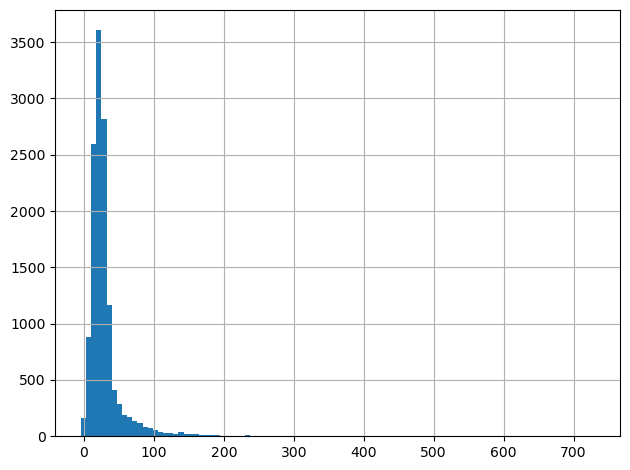

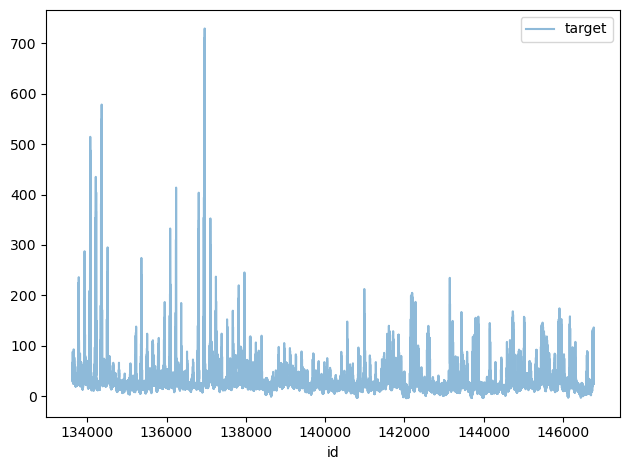

mean: 30.401734794439225
median: 23.493495962837066
std: 34.373980624570386
min: -4.368157083979494
max: 729.6278747309177


In [6]:
sub_best["target"].hist(bins=100)
plt.tight_layout()
plt.show()

sub_best.plot(x="id", y="target", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"mean: {sub_best['target'].mean()}")
print(f"median: {sub_best['target'].median()}")
print(f"std: {sub_best['target'].std()}")
print(f"min: {sub_best['target'].min()}")
print(f"max: {sub_best['target'].max()}")





In [7]:
# Model-drop analysis: per market, find worst model and test dropping it (ensemble of best 2)
# Run per-market cell first. Reports which model to drop and whether 2-model ensemble beats all-3.
print("Model-drop: worst model per market, all3 vs best2 RMSE")
def _rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))

drop_results = []
for mkt in markets:
    tr = train_full[train_full["market"] == mkt].copy()
    va = val_full[val_full["market"] == mkt].copy()
    te = test_full[test_full["market"] == mkt].copy()
    tr = pd.concat([tr, va], ignore_index=True).sort_values("delivery_start").reset_index(drop=True)
    n = len(tr)
    cut = int(np.floor((1 - VAL_FRAC) * n))
    X_te = te[feat_cols]
    y_te = te["target"]
    if len(X_te) > EMBARGO:
        X_te = X_te.iloc[EMBARGO:].reset_index(drop=True)
        y_te = y_te.iloc[EMBARGO:].reset_index(drop=True)

    y_min_m = y_min_per_market.get(mkt) if TARGET_TRANSFORM == "log_shifted" else None
    p_xgb = inv_pred(models_xgb[mkt].predict(xgb.DMatrix(X_te)), y_min_override=y_min_m)
    p_lgb = inv_pred(models_lgb[mkt].predict(X_te), y_min_override=y_min_m)
    p_cb = inv_pred(models_cb[mkt].predict(X_te), y_min_override=y_min_m)
    y_te_arr = y_te.values

    rmse_xgb = _rmse(y_te_arr, p_xgb)
    rmse_lgb = _rmse(y_te_arr, p_lgb)
    rmse_cb = _rmse(y_te_arr, p_cb)
    rmse_all3 = _rmse(y_te_arr, (p_xgb + p_lgb + p_cb) / 3)

    ranks = [("xgb", rmse_xgb), ("lgb", rmse_lgb), ("cb", rmse_cb)]
    ranks.sort(key=lambda x: x[1], reverse=True)  # worst first
    worst = ranks[0][0]
    best2 = [r[0] for r in ranks[1:]]
    preds = {"xgb": p_xgb, "lgb": p_lgb, "cb": p_cb}
    p_best2 = (preds[best2[0]] + preds[best2[1]]) / 2
    rmse_best2 = _rmse(y_te_arr, p_best2)
    improves = rmse_best2 < rmse_all3

    drop_results.append({
        "market": mkt, "worst": worst, "best2": best2,
        "rmse_xgb": rmse_xgb, "rmse_lgb": rmse_lgb, "rmse_cb": rmse_cb,
        "rmse_all3": rmse_all3, "rmse_best2": rmse_best2, "improves": improves,
    })
    print(f"  {mkt}: worst={worst}  all3={rmse_all3:.2f}  best2={rmse_best2:.2f}  drop_helps={improves}")

print("\nSummary: markets where dropping worst model improves:")
for r in drop_results:
    if r["improves"]:
        print(f"  {r['market']}: drop {r['worst']} -> RMSE {r['rmse_all3']:.2f} -> {r['rmse_best2']:.2f}")

Model-drop: worst model per market, all3 vs best2 RMSE
  Market A: worst=xgb  all3=95.18  best2=93.78  drop_helps=True
  Market B: worst=xgb  all3=62.19  best2=61.68  drop_helps=True
  Market C: worst=xgb  all3=47.08  best2=46.83  drop_helps=True
  Market D: worst=xgb  all3=62.99  best2=58.99  drop_helps=True
  Market E: worst=xgb  all3=62.76  best2=60.71  drop_helps=True
  Market F: worst=xgb  all3=27.70  best2=22.77  drop_helps=True

Summary: markets where dropping worst model improves:
  Market A: drop xgb -> RMSE 95.18 -> 93.78
  Market B: drop xgb -> RMSE 62.19 -> 61.68
  Market C: drop xgb -> RMSE 47.08 -> 46.83
  Market D: drop xgb -> RMSE 62.99 -> 58.99
  Market E: drop xgb -> RMSE 62.76 -> 60.71
  Market F: drop xgb -> RMSE 27.70 -> 22.77


In [8]:
# Stacking with best-2 models only (drop worst per market). Run model-drop cell first.
# Compares: simple avg | Ridge | MLP on 2-model inputs, then saves best to submission.
import os
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

stack_drop_results = []
all_p_avg_drop, all_p_ridge_drop, all_p_mlp_drop, all_y_te_drop = [], [], [], []
models_ridge_drop, models_mlp_drop = {}, {}

print("Stacking (best-2 only): per-market RMSE (avg | ridge | mlp | best)")
for r in drop_results:
    mkt = r["market"]
    best2 = r["best2"]
    tr = train_full[train_full["market"] == mkt].copy()
    va = val_full[val_full["market"] == mkt].copy()
    te = test_full[test_full["market"] == mkt].copy()
    tr = pd.concat([tr, va], ignore_index=True).sort_values("delivery_start").reset_index(drop=True)
    n = len(tr)
    cut = int(np.floor((1 - VAL_FRAC) * n))
    X_va = tr.iloc[cut:][feat_cols]
    y_va = tr.iloc[cut:]["target"]
    X_te = te[feat_cols]
    y_te = te["target"]
    if len(X_va) > EMBARGO:
        X_va = X_va.iloc[EMBARGO:].reset_index(drop=True)
        y_va = y_va.iloc[EMBARGO:].reset_index(drop=True)
    if len(X_te) > EMBARGO:
        X_te = X_te.iloc[EMBARGO:].reset_index(drop=True)
        y_te = y_te.iloc[EMBARGO:].reset_index(drop=True)

    y_min_m = y_min_per_market.get(mkt) if TARGET_TRANSFORM == "log_shifted" else None
    preds_va = {}
    preds_te = {}
    for name in best2:
        if name == "xgb":
            preds_va[name] = inv_pred(models_xgb[mkt].predict(xgb.DMatrix(X_va)), y_min_override=y_min_m)
            preds_te[name] = inv_pred(models_xgb[mkt].predict(xgb.DMatrix(X_te)), y_min_override=y_min_m)
        elif name == "lgb":
            preds_va[name] = inv_pred(models_lgb[mkt].predict(X_va), y_min_override=y_min_m)
            preds_te[name] = inv_pred(models_lgb[mkt].predict(X_te), y_min_override=y_min_m)
        else:
            preds_va[name] = inv_pred(models_cb[mkt].predict(X_va), y_min_override=y_min_m)
            preds_te[name] = inv_pred(models_cb[mkt].predict(X_te), y_min_override=y_min_m)

    P_va = np.column_stack([preds_va[best2[0]], preds_va[best2[1]]])
    P_te = np.column_stack([preds_te[best2[0]], preds_te[best2[1]]])
    p_avg = (preds_te[best2[0]] + preds_te[best2[1]]) / 2
    rmse_avg = _rmse(y_te.values, p_avg)
    all_p_avg_drop.append(p_avg)
    all_y_te_drop.append(y_te.values)

    ridge = Ridge(alpha=1.0).fit(P_va, y_va)
    models_ridge_drop[mkt] = ridge
    p_ridge = ridge.predict(P_te)
    rmse_ridge = _rmse(y_te.values, p_ridge)
    all_p_ridge_drop.append(p_ridge)

    mlp = MLPRegressor(hidden_layer_sizes=(32, 16), alpha=0.1, max_iter=500, early_stopping=True, random_state=42)
    mlp.fit(P_va, y_va)
    models_mlp_drop[mkt] = mlp
    p_mlp = mlp.predict(P_te)
    rmse_mlp = _rmse(y_te.values, p_mlp)
    all_p_mlp_drop.append(p_mlp)

    best = min([("avg", rmse_avg), ("ridge", rmse_ridge), ("mlp", rmse_mlp)], key=lambda x: x[1])[0]
    stack_drop_results.append({"market": mkt, "best2": best2, "rmse_avg": rmse_avg, "rmse_ridge": rmse_ridge, "rmse_mlp": rmse_mlp, "best": best})
    print(f"  {mkt}: avg={rmse_avg:.2f}  ridge={rmse_ridge:.2f}  mlp={rmse_mlp:.2f}  best={best}  (using {best2})")

y_te_drop = np.concatenate(all_y_te_drop)
p_avg_drop = np.concatenate(all_p_avg_drop)
p_ridge_drop = np.concatenate(all_p_ridge_drop)
p_mlp_drop = np.concatenate(all_p_mlp_drop)
print("\nOverall test RMSE (best-2 only):")
print(f"  Simple avg: {_rmse(y_te_drop, p_avg_drop):.2f}")
print(f"  Ridge:      {_rmse(y_te_drop, p_ridge_drop):.2f}")
print(f"  MLP:        {_rmse(y_te_drop, p_mlp_drop):.2f}")

# Pick overall best: avg vs Ridge vs MLP
rmse_avg_all = _rmse(y_te_drop, p_avg_drop)
rmse_ridge_all = _rmse(y_te_drop, p_ridge_drop)
rmse_mlp_all = _rmse(y_te_drop, p_mlp_drop)
best_method = min([("avg", rmse_avg_all), ("ridge", rmse_ridge_all), ("mlp", rmse_mlp_all)], key=lambda x: x[1])[0]
print(f"\nOverall best: {best_method}")

# Save best method to test_pred
real_preds_drop = []
for mkt in sorted(test_pred_full["market"].unique()):
    if mkt not in models_mlp_drop:
        continue
    r = next(dr for dr in drop_results if dr["market"] == mkt)
    best2 = r["best2"]
    mask = test_pred_full["market"] == mkt
    X_real = test_pred_full.loc[mask, feat_cols]
    ids_m = test_pred_full.loc[mask, "id"].values
    y_min_m = y_min_per_market.get(mkt) if TARGET_TRANSFORM == "log_shifted" else None
    preds_real = {}
    for name in best2:
        if name == "xgb":
            preds_real[name] = inv_pred(models_xgb[mkt].predict(xgb.DMatrix(X_real)), y_min_override=y_min_m)
        elif name == "lgb":
            preds_real[name] = inv_pred(models_lgb[mkt].predict(X_real), y_min_override=y_min_m)
        else:
            preds_real[name] = inv_pred(models_cb[mkt].predict(X_real), y_min_override=y_min_m)
    P_real = np.column_stack([preds_real[best2[0]], preds_real[best2[1]]])
    p_avg = (preds_real[best2[0]] + preds_real[best2[1]]) / 2
    p_ridge = models_ridge_drop[mkt].predict(P_real)
    p_mlp = models_mlp_drop[mkt].predict(P_real)
    p_final = p_mlp if best_method == "mlp" else (p_ridge if best_method == "ridge" else p_avg)
    real_preds_drop.append(pd.DataFrame({"id": ids_m, "target": p_final}))

sub_drop = pd.concat(real_preds_drop, ignore_index=True).sort_values("id").reset_index(drop=True)
os.makedirs("submissions", exist_ok=True)
# sub_drop.to_csv(f"submissions/submission_best2_{best_method}_stack_3.csv", index=False)
print(f"Saved {len(sub_drop)} rows -> submissions/submission_best2_{best_method}_stack.csv")

Stacking (best-2 only): per-market RMSE (avg | ridge | mlp | best)
  Market A: avg=93.78  ridge=94.95  mlp=95.63  best=avg  (using ['lgb', 'cb'])
  Market B: avg=61.68  ridge=72.35  mlp=69.90  best=avg  (using ['lgb', 'cb'])
  Market C: avg=46.83  ridge=50.39  mlp=46.09  best=mlp  (using ['lgb', 'cb'])
  Market D: avg=58.99  ridge=95.31  mlp=82.48  best=avg  (using ['lgb', 'cb'])
  Market E: avg=60.71  ridge=61.89  mlp=68.15  best=avg  (using ['lgb', 'cb'])
  Market F: avg=22.77  ridge=26.02  mlp=23.72  best=avg  (using ['lgb', 'cb'])

Overall test RMSE (best-2 only):
  Simple avg: 62.77
  Ridge:      72.99
  MLP:        70.31

Overall best: avg
Saved 13098 rows -> submissions/submission_best2_avg_stack.csv


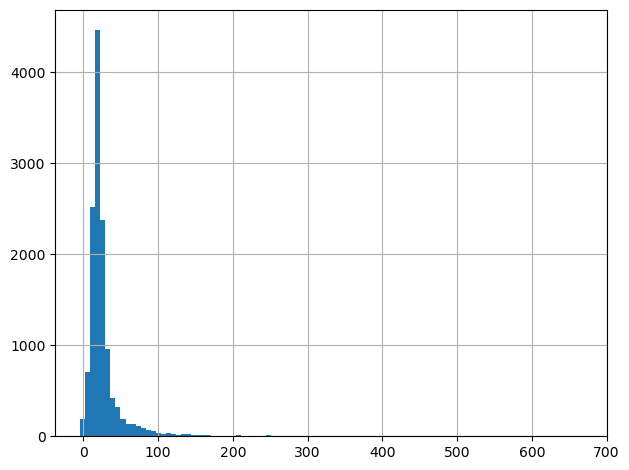

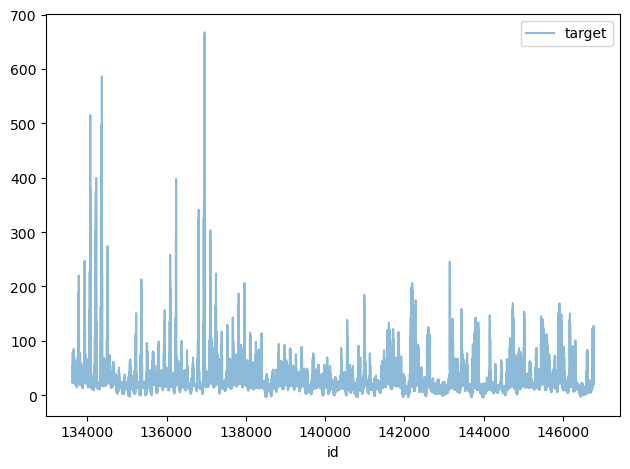

max: 667.5953572748588
min: -4.152227455572543
mean: 27.433016124090553
std: 31.31736978337511
median: 20.57183549951689


In [9]:
sub_drop["target"].hist(bins=100)
plt.tight_layout()
plt.show()

sub_drop.plot(x="id", y="target", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"max: {sub_drop['target'].max()}")
print(f"min: {sub_drop['target'].min()}")
print(f"mean: {sub_drop['target'].mean()}")
print(f"std: {sub_drop['target'].std()}")
print(f"median: {sub_drop['target'].median()}")


=== Market A: error stats ===
MAE=39.78, RMSE=87.19
Bias (mean error): 28.84 (positive = underprediction)


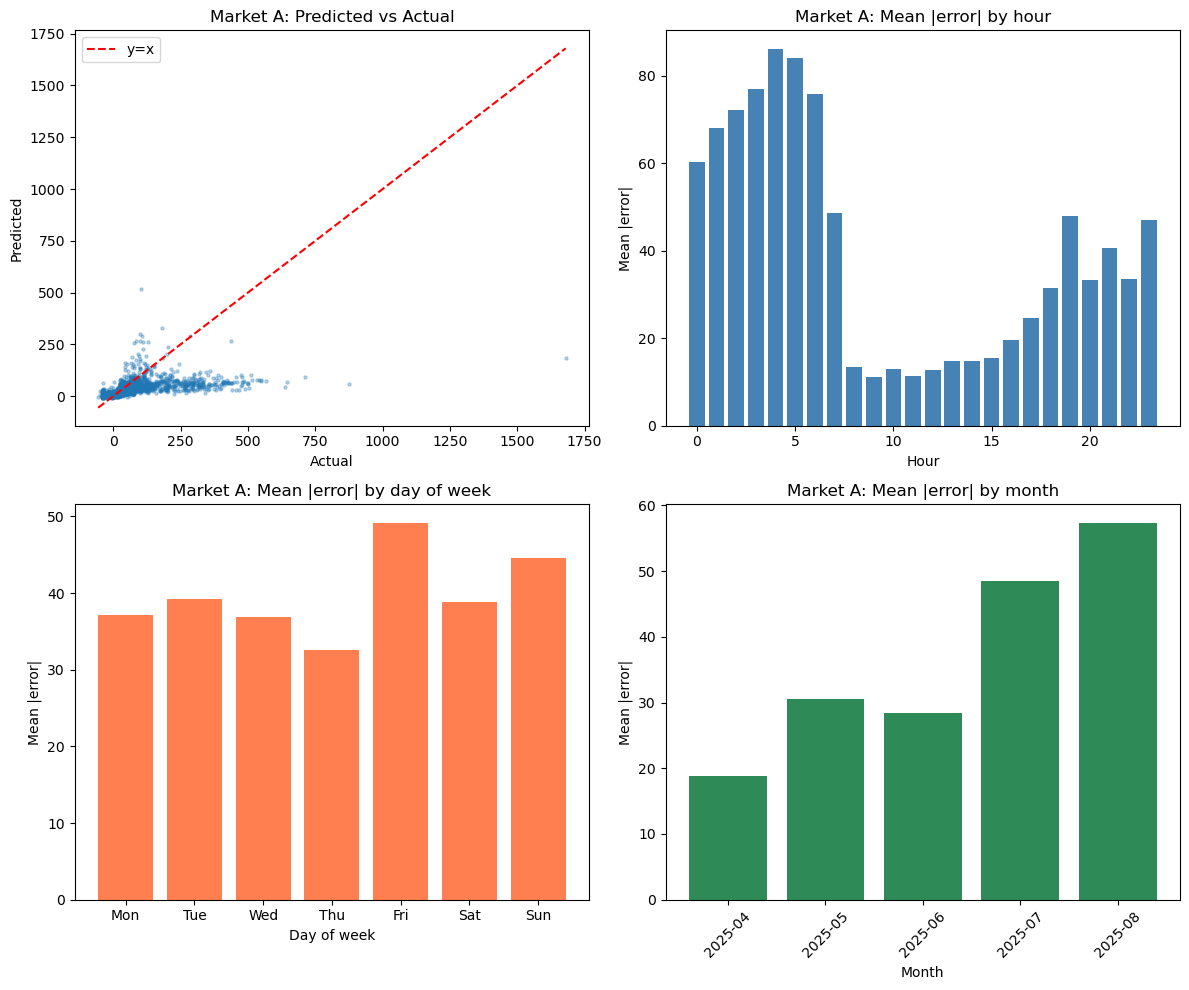

In [11]:
# Inspect where Market A fails: errors by hour, day, month; predicted vs actual
market_to_check = "Market A"
test_full["delivery_start"] = pd.to_datetime(test_full["delivery_start"])
mkt_a_idx = [i for i, s in enumerate(per_mkt_scores) if s["market"] == market_to_check][0]
p_a = all_p_te[mkt_a_idx]

te_a = test_full[test_full["market"] == market_to_check].copy().reset_index(drop=True)
# Per-market training drops first EMBARGO rows (lag/rolling warm-up); align te_a with p_a
# EMBARGO = 48
if len(te_a) > EMBARGO:
    te_a = te_a.iloc[EMBARGO:].reset_index(drop=True)
te_a["y_pred"] = p_a
te_a["error"] = te_a["target"] - te_a["y_pred"]
te_a["abs_error"] = te_a["error"].abs()
te_a["hour"] = te_a["delivery_start"].dt.hour
te_a["dow"] = te_a["delivery_start"].dt.dayofweek
te_a["month"] = te_a["delivery_start"].dt.to_period("M")

print("=== Market A: error stats ===")
print(f"MAE={te_a['abs_error'].mean():.2f}, RMSE={np.sqrt((te_a['error']**2).mean()):.2f}")
print(f"Bias (mean error): {te_a['error'].mean():.2f} (positive = underprediction)")

# Predicted vs actual scatter
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].scatter(te_a["target"], te_a["y_pred"], alpha=0.3, s=5)
axes[0, 0].plot([te_a["target"].min(), te_a["target"].max()], [te_a["target"].min(), te_a["target"].max()], "r--", label="y=x")
axes[0, 0].set_xlabel("Actual"); axes[0, 0].set_ylabel("Predicted")
axes[0, 0].set_title("Market A: Predicted vs Actual")
axes[0, 0].legend()

# Mean abs error by hour
by_hour = te_a.groupby("hour")["abs_error"].mean()
axes[0, 1].bar(by_hour.index, by_hour.values, color="steelblue")
axes[0, 1].set_xlabel("Hour"); axes[0, 1].set_ylabel("Mean |error|")
axes[0, 1].set_title("Market A: Mean |error| by hour")

# Mean abs error by day of week
by_dow = te_a.groupby("dow")["abs_error"].mean()
axes[1, 0].bar(by_dow.index, by_dow.values, color="coral")
axes[1, 0].set_xticks(range(7)); axes[1, 0].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
axes[1, 0].set_xlabel("Day of week"); axes[1, 0].set_ylabel("Mean |error|")
axes[1, 0].set_title("Market A: Mean |error| by day of week")

# Mean abs error by month
by_month = te_a.groupby("month")["abs_error"].mean()
axes[1, 1].bar(range(len(by_month)), by_month.values, color="seagreen")
axes[1, 1].set_xticks(range(len(by_month)))
axes[1, 1].set_xticklabels([str(m) for m in by_month.index], rotation=45)
axes[1, 1].set_xlabel("Month"); axes[1, 1].set_ylabel("Mean |error|")
axes[1, 1].set_title("Market A: Mean |error| by month")
plt.tight_layout()
plt.show()

In [4]:
# ── Write submission files ─────────────────────────────────────────────────────
sample_sub = pd.read_csv("submissions/sample_submission_targets.csv")
def save_sub(sub, fname):
    # sub = pd.DataFrame({"id": X_test_pred["id"], "target": preds})
    # Check format
    assert list(sub.columns) == ['id', 'target'], "Wrong columns!"
    assert len(sub) == 13098, f"Wrong row count: {len(sub)}"
    assert sub['id'].min() == 133627, "IDs must start at 133627"
    assert sub['id'].max() == 146778, "IDs must end at 146778"
    assert sub['target'].notna().all(), "No NaN values allowed!"
    assert np.isfinite(sub['target']).all(), "No infinite values allowed!"
    print("✅ Validation passed!")

    sub.to_csv(f"submissions/{fname}", index=False)
    print(f"Saved {fname}  ({len(sub)} rows)")

save_sub(sub_per_mkt, "submission_per_market_ensemble_mean_rmse_multi_seeds_20pct_7.csv")

✅ Validation passed!
Saved submission_per_market_ensemble_mean_rmse_multi_seeds_20pct_7.csv  (13098 rows)


In [1]:
# Merge: TabPFN for Market A + ensemble for other markets → new submission
import pandas as pd

test_pred = pd.read_csv("dataset/processed/test_pred.csv")
if "market" not in test_pred.columns:
    raise ValueError("test_pred.csv needs 'market' column")

tabpfn_a = pd.read_csv("submissions/tabpfn_per_market/predictions_Market_A.csv")
ensemble = pd.read_csv("submissions/submission_per_market_ensemble_mean_rmse_multi_seeds_20pct_5.csv")

# Map id -> market
id_to_market = test_pred.set_index("id")["market"].to_dict()

# Build merged: TabPFN for Market A ids, ensemble for rest
merged = ensemble.copy()
ids_market_a = [i for i in merged["id"] if id_to_market.get(i) == "Market A"]
tabpfn_a_dict = tabpfn_a.set_index("id")["target"].to_dict()
mask_a = merged["id"].isin(ids_market_a)
merged.loc[mask_a, "target"] = merged.loc[mask_a, "id"].map(tabpfn_a_dict)

merged = merged.sort_values("id").reset_index(drop=True)
out_path = "submissions/submission_TabPFN_MarketA_ensemble_rest.csv"
merged.to_csv(out_path, index=False)
print(f"✅ Saved {out_path} ({len(merged)} rows)")
print(f"   Market A (TabPFN): {len(ids_market_a)} rows, rest (ensemble): {len(merged) - len(ids_market_a)} rows")

✅ Saved submissions/submission_TabPFN_MarketA_ensemble_rest.csv (13098 rows)
   Market A (TabPFN): 2183 rows, rest (ensemble): 10915 rows


In [5]:
print(f"max: {sub_per_mkt['target'].max()}")
print(f"min: {sub_per_mkt['target'].min()}")
print(f"mean: {sub_per_mkt['target'].mean()}")
print(f"std: {sub_per_mkt['target'].std()}")
print(f"median: {sub_per_mkt['target'].median()}")

max: 245.12434993231093
min: -28.62207814014754
mean: 20.869803758819202
std: 17.509989569073646
median: 18.498971411635736


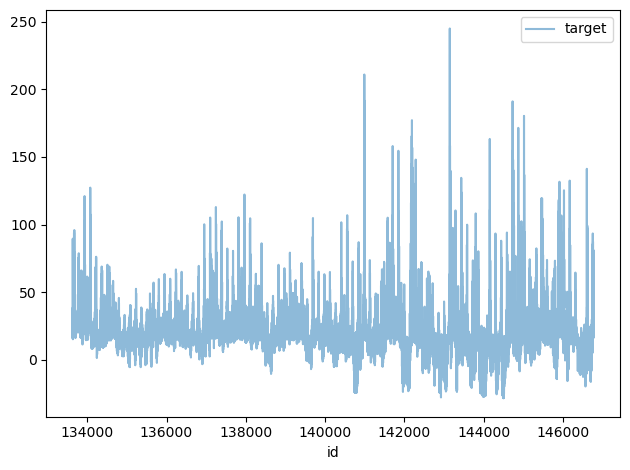

In [6]:
sub_per_mkt.plot(x="id", y="target", alpha=0.5)
plt.tight_layout()
plt.show()


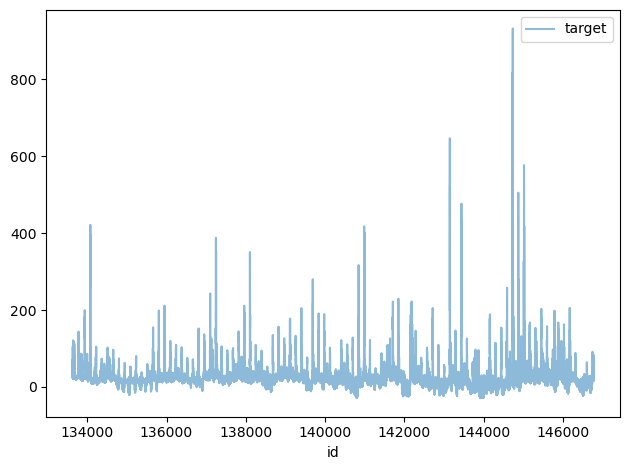

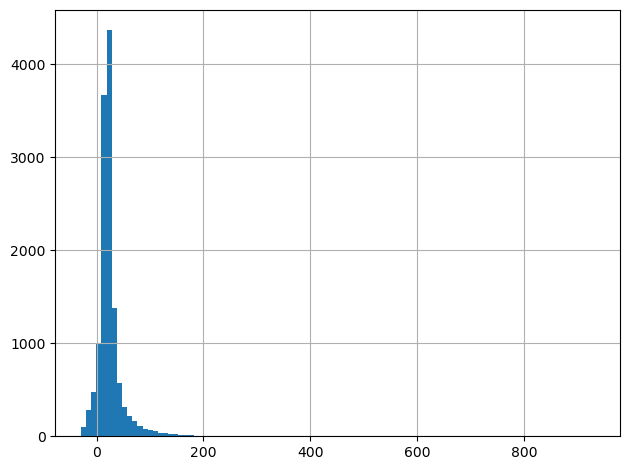

In [12]:
tmp = pd.read_csv("submissions/tabpfn_per_market/total_prediction.csv")
tmp.plot(x="id", y="target", alpha=0.5)
plt.tight_layout()
plt.show()

tmp["target"].hist(bins=100)
plt.tight_layout()
plt.show()

## Quantile models (per-market, weighted average + stacking)

Train XGB / LGBM / CatBoost in quantile mode for multiple quantiles per market.
Combine via weighted average, then stack with Ridge + MLP (same pattern as point models).

In [5]:
# Per-market quantile training: XGB, LGBM, CatBoost per quantile per market
# Run per-market (point model) cell first to set up data / feat_cols / markets / etc.
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

QUANTILE_ALPHAS = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)
QUANTILE_WEIGHTS = np.array([0.1, 0.1, 0, 0.2, 0.2, 0.2, 0, 0.1, 0.1], dtype=float)
QUANTILE_COMBINE = "ridge"  # "fixed" | "ridge" | "mlp" — how to combine quantile preds per model type
assert len(QUANTILE_ALPHAS) == len(QUANTILE_WEIGHTS)

q_models_xgb = {}  # {mkt: {alpha: model}}
q_models_lgb = {}
q_models_cb = {}
q_combiners = {"xgb": {}, "lgb": {}, "cb": {}}

def _rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))

def _combine_q(preds_by_alpha, alphas, weights, combiner=None):
    """Combine quantile predictions: fixed weighted avg or learned combiner."""
    if combiner is not None:
        P = np.column_stack([preds_by_alpha[a] for a in alphas])
        return combiner.predict(P)
    return np.average([preds_by_alpha[a] for a in alphas], axis=0, weights=weights)

def _q_predict_xgb(mkt, a, X):
    return np.mean([m.predict(xgb.DMatrix(X)) for m in q_models_xgb[mkt][a]], axis=0)

def _q_predict_lgb(mkt, a, X):
    return np.mean([m.predict(X) for m in q_models_lgb[mkt][a]], axis=0)

def _q_predict_cb(mkt, a, X):
    return np.mean([m.predict(X) for m in q_models_cb[mkt][a]], axis=0)

print(f"Quantile per-market training (combine={QUANTILE_COMBINE}, seeds={SEEDS}):")
for mkt in markets:
    tr = train_full[train_full["market"] == mkt].copy()
    va = val_full[val_full["market"] == mkt].copy()
    te = test_full[test_full["market"] == mkt].copy()
    tr = pd.concat([tr, va], ignore_index=True).sort_values("delivery_start").reset_index(drop=True)

    X_m = tr[feat_cols]
    y_m = tr["target"]
    n = len(X_m)
    cut = int(np.floor((1 - VAL_FRAC) * n))
    X_tr, y_tr = X_m.iloc[:cut], y_m.iloc[:cut]
    X_va, y_va = X_m.iloc[cut:], y_m.iloc[cut:]
    X_te = te[feat_cols]
    y_te = te["target"]

    if len(X_te) > EMBARGO:
        X_te = X_te.iloc[EMBARGO:].reset_index(drop=True)
        y_te = y_te.iloc[EMBARGO:].reset_index(drop=True)

    q_models_xgb[mkt] = {}
    q_models_lgb[mkt] = {}
    q_models_cb[mkt] = {}
    preds_xgb_va, preds_lgb_va, preds_cb_va = {}, {}, {}
    preds_xgb_te, preds_lgb_te, preds_cb_te = {}, {}, {}

    for a in QUANTILE_ALPHAS:
        _xgb_ms, _lgb_ms, _cb_ms = [], [], []
        _xgb_va_s, _lgb_va_s, _cb_va_s = [], [], []
        _xgb_te_s, _lgb_te_s, _cb_te_s = [], [], []
        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_va, label=y_va)
        dte = xgb.DMatrix(X_te)
        for seed in SEEDS:
            bst = xgb.train({"objective": "reg:quantileerror", "quantile_alpha": float(a),
                              "tree_method": "hist", "max_depth": 6, "eta": 0.05,
                              "subsample": 0.8, "colsample_bytree": 0.8, "seed": seed},
                             dtrain, num_boost_round=2000,
                             evals=[(dval, "val")], early_stopping_rounds=150, verbose_eval=False)
            _xgb_ms.append(bst); _xgb_va_s.append(bst.predict(dval)); _xgb_te_s.append(bst.predict(dte))

            lgb_m = lgb.LGBMRegressor(
                objective="quantile", alpha=a, n_estimators=2000, max_depth=6,
                learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                random_state=seed, n_jobs=-1, verbose=-1)
            lgb_m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                      callbacks=[lgb.early_stopping(150, verbose=False)])
            _lgb_ms.append(lgb_m); _lgb_va_s.append(lgb_m.predict(X_va)); _lgb_te_s.append(lgb_m.predict(X_te))

            cb_m = cb.CatBoostRegressor(
                loss_function=f"Quantile:alpha={a}", iterations=2000, depth=6,
                learning_rate=0.05, subsample=0.8, random_seed=seed, verbose=0)
            cb_m.fit(X_tr, y_tr, eval_set=(X_va, y_va),
                     use_best_model=True, early_stopping_rounds=150)
            _cb_ms.append(cb_m); _cb_va_s.append(cb_m.predict(X_va)); _cb_te_s.append(cb_m.predict(X_te))

        q_models_xgb[mkt][a] = _xgb_ms
        q_models_lgb[mkt][a] = _lgb_ms
        q_models_cb[mkt][a] = _cb_ms
        preds_xgb_va[a] = np.mean(_xgb_va_s, axis=0)
        preds_xgb_te[a] = np.mean(_xgb_te_s, axis=0)
        preds_lgb_va[a] = np.mean(_lgb_va_s, axis=0)
        preds_lgb_te[a] = np.mean(_lgb_te_s, axis=0)
        preds_cb_va[a] = np.mean(_cb_va_s, axis=0)
        preds_cb_te[a] = np.mean(_cb_te_s, axis=0)

    if QUANTILE_COMBINE != "fixed":
        from sklearn.linear_model import Ridge as _Ridge
        from sklearn.neural_network import MLPRegressor as _MLP
        _make = lambda: (_Ridge(alpha=1.0) if QUANTILE_COMBINE == "ridge"
                         else _MLP(hidden_layer_sizes=(32, 16), alpha=0.1,
                                   max_iter=500, early_stopping=True, random_state=42))
        for _key, _pva in [("xgb", preds_xgb_va), ("lgb", preds_lgb_va), ("cb", preds_cb_va)]:
            _P = np.column_stack([_pva[a] for a in QUANTILE_ALPHAS])
            _comb = _make()
            _comb.fit(_P, y_va.values)
            q_combiners[_key][mkt] = _comb

    p_xgb_w = _combine_q(preds_xgb_te, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["xgb"].get(mkt))
    p_lgb_w = _combine_q(preds_lgb_te, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["lgb"].get(mkt))
    p_cb_w = _combine_q(preds_cb_te, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["cb"].get(mkt))
    y_arr = y_te.values
    r_x, r_l, r_c = _rmse(y_arr, p_xgb_w), _rmse(y_arr, p_lgb_w), _rmse(y_arr, p_cb_w)
    r_ens = _rmse(y_arr, (p_xgb_w + p_lgb_w + p_cb_w) / 3)
    print(f"  {mkt}: xgb_q={r_x:.2f}  lgb_q={r_l:.2f}  cb_q={r_c:.2f}  ens={r_ens:.2f}")

print("\nQuantile per-market training done.")

Quantile per-market training (combine=ridge, seeds=[19, 26, 42, 123, 456]):


KeyboardInterrupt: 

In [6]:
# Quantile stacking: Ridge + MLP on weighted-average quantile predictions per market
# Run quantile training cell first.
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

def _rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))

print("Quantile stacking: per-market RMSE (avg | ridge | mlp | best)")
q_stack_results = []
q_models_ridge, q_models_mlp = {}, {}
q_all_p_ridge, q_all_p_mlp, q_all_p_avg, q_all_p_best, q_all_y_te = [], [], [], [], []

for mkt in markets:
    tr = train_full[train_full["market"] == mkt].copy()
    va = val_full[val_full["market"] == mkt].copy()
    te = test_full[test_full["market"] == mkt].copy()
    tr = pd.concat([tr, va], ignore_index=True).sort_values("delivery_start").reset_index(drop=True)
    n = len(tr)
    cut = int(np.floor((1 - VAL_FRAC) * n))
    X_va = tr.iloc[cut:][feat_cols]
    y_va = tr.iloc[cut:]["target"]
    X_te = te[feat_cols]
    y_te = te["target"]
    if len(X_va) > EMBARGO:
        X_va = X_va.iloc[EMBARGO:].reset_index(drop=True)
        y_va = y_va.iloc[EMBARGO:].reset_index(drop=True)
    if len(X_te) > EMBARGO:
        X_te = X_te.iloc[EMBARGO:].reset_index(drop=True)
        y_te = y_te.iloc[EMBARGO:].reset_index(drop=True)

    _pxv = {a: _q_predict_xgb(mkt, a, X_va) for a in QUANTILE_ALPHAS}
    _plv = {a: _q_predict_lgb(mkt, a, X_va) for a in QUANTILE_ALPHAS}
    _pcv = {a: _q_predict_cb(mkt, a, X_va) for a in QUANTILE_ALPHAS}
    _pxt = {a: _q_predict_xgb(mkt, a, X_te) for a in QUANTILE_ALPHAS}
    _plt = {a: _q_predict_lgb(mkt, a, X_te) for a in QUANTILE_ALPHAS}
    _pct = {a: _q_predict_cb(mkt, a, X_te) for a in QUANTILE_ALPHAS}

    p_xgb_va = _combine_q(_pxv, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["xgb"].get(mkt))
    p_lgb_va = _combine_q(_plv, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["lgb"].get(mkt))
    p_cb_va = _combine_q(_pcv, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["cb"].get(mkt))

    p_xgb_te = _combine_q(_pxt, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["xgb"].get(mkt))
    p_lgb_te = _combine_q(_plt, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["lgb"].get(mkt))
    p_cb_te = _combine_q(_pct, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["cb"].get(mkt))

    P_va = np.column_stack([p_xgb_va, p_lgb_va, p_cb_va])
    P_te = np.column_stack([p_xgb_te, p_lgb_te, p_cb_te])

    p_avg_te = (p_xgb_te + p_lgb_te + p_cb_te) / 3
    rmse_avg = _rmse(y_te, p_avg_te)
    q_all_p_avg.append(p_avg_te)

    ridge = Ridge(alpha=1.0).fit(P_va, y_va)
    q_models_ridge[mkt] = ridge
    p_ridge_te = ridge.predict(P_te)
    rmse_ridge = _rmse(y_te, p_ridge_te)
    q_all_p_ridge.append(p_ridge_te)
    q_all_y_te.append(y_te.values)

    mlp = MLPRegressor(hidden_layer_sizes=(32, 16), alpha=0.1, max_iter=500, early_stopping=True, random_state=42)
    mlp.fit(P_va, y_va)
    q_models_mlp[mkt] = mlp
    p_mlp_te = mlp.predict(P_te)
    rmse_mlp = _rmse(y_te, p_mlp_te)
    q_all_p_mlp.append(p_mlp_te)

    best = min([("avg", rmse_avg), ("ridge", rmse_ridge), ("mlp", rmse_mlp)], key=lambda x: x[1])[0]
    p_best_te = p_ridge_te if best == "ridge" else (p_mlp_te if best == "mlp" else p_avg_te)
    q_all_p_best.append(p_best_te)
    q_stack_results.append({"market": mkt, "rmse_avg": rmse_avg, "rmse_ridge": rmse_ridge, "rmse_mlp": rmse_mlp, "best": best})
    print(f"  {mkt}: avg={rmse_avg:.2f}  ridge={rmse_ridge:.2f}  mlp={rmse_mlp:.2f}  best={best}")

y_q_all = np.concatenate(q_all_y_te)
print(f"\nOverall quantile test RMSE:")
print(f"  Simple avg:       {_rmse(y_q_all, np.concatenate(q_all_p_avg)):.2f}")
print(f"  Ridge stack:      {_rmse(y_q_all, np.concatenate(q_all_p_ridge)):.2f}")
print(f"  MLP stack:        {_rmse(y_q_all, np.concatenate(q_all_p_mlp)):.2f}")
print(f"  Best-per-market:  {_rmse(y_q_all, np.concatenate(q_all_p_best)):.2f}")

Quantile stacking: per-market RMSE (avg | ridge | mlp | best)
  Market A: avg=78.30  ridge=78.80  mlp=77.78  best=mlp
  Market B: avg=37.01  ridge=37.20  mlp=37.09  best=avg
  Market C: avg=19.76  ridge=20.15  mlp=19.94  best=avg
  Market D: avg=22.35  ridge=22.60  mlp=22.79  best=avg
  Market E: avg=36.17  ridge=36.23  mlp=36.40  best=avg
  Market F: avg=20.04  ridge=20.78  mlp=20.78  best=avg

Overall quantile test RMSE:
  Simple avg:       41.21
  Ridge stack:      41.52
  MLP stack:        41.20
  Best-per-market:  41.04


In [ ]:
# Predict on real test using best quantile stacking method per market. Run quantile stacking cell first.
# Saves submission to submissions/submission_quantile_stack.csv
q_best_per_market = {r["market"]: r["best"] for r in q_stack_results}
q_real_preds = []
markets_in_test = sorted(test_pred_full["market"].unique())
for mkt in markets_in_test:
    if mkt not in q_best_per_market:
        print(f"Warning: no quantile model for market '{mkt}', skipping")
        continue
    mask = test_pred_full["market"] == mkt
    if mask.sum() == 0:
        continue
    X_real = test_pred_full.loc[mask, feat_cols]
    ids_m = test_pred_full.loc[mask, "id"].values

    _px = {a: _q_predict_xgb(mkt, a, X_real) for a in QUANTILE_ALPHAS}
    _pl = {a: _q_predict_lgb(mkt, a, X_real) for a in QUANTILE_ALPHAS}
    _pc = {a: _q_predict_cb(mkt, a, X_real) for a in QUANTILE_ALPHAS}
    p_xgb = _combine_q(_px, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["xgb"].get(mkt))
    p_lgb = _combine_q(_pl, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["lgb"].get(mkt))
    p_cb = _combine_q(_pc, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners["cb"].get(mkt))
    P_real = np.column_stack([p_xgb, p_lgb, p_cb])
    p_avg = (p_xgb + p_lgb + p_cb) / 3
    p_ridge = q_models_ridge[mkt].predict(P_real)
    p_mlp = q_models_mlp[mkt].predict(P_real)
    best = q_best_per_market[mkt]
    p_final = p_ridge if best == "ridge" else (p_mlp if best == "mlp" else p_avg)
    q_real_preds.append(pd.DataFrame({"id": ids_m, "target": p_final}))

sub_quantile = pd.concat(q_real_preds, ignore_index=True).sort_values("id").reset_index(drop=True)
os.makedirs("submissions", exist_ok=True)
sub_quantile.to_csv("submissions/submission_quantile_stack_ridge_5.csv", index=False)
print(f"Quantile stack submission saved: {len(sub_quantile)} rows -> submissions/submission_quantile_stack.csv")
print(f"Per-market choices: {q_best_per_market}")

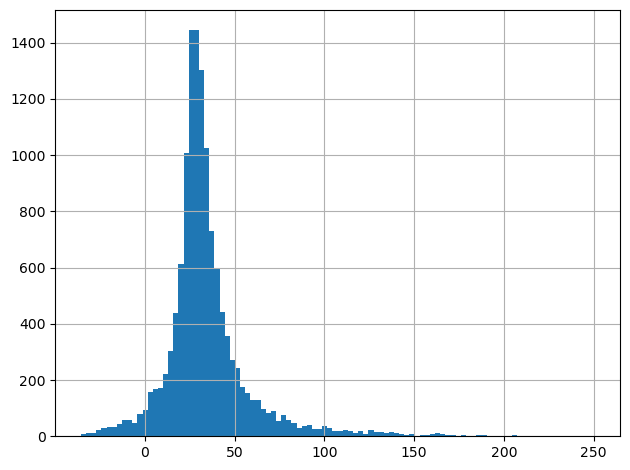

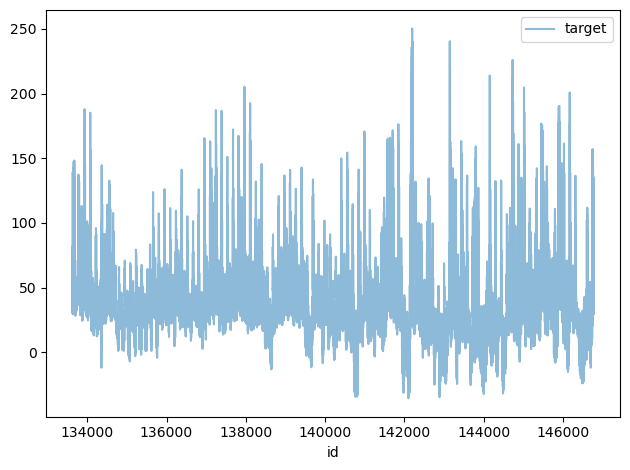

mean: 34.35209480014428
median: 30.264994312551444
std: 24.79674179093541
min: -35.59182559609643
max: 250.31940642245561


In [ ]:
sub_quantile["target"].hist(bins=100)
plt.tight_layout()
plt.show()

sub_quantile.plot(x="id", y="target", alpha=0.5)
plt.tight_layout()
plt.show()


print(f"mean: {sub_quantile['target'].mean()}")
print(f"median: {sub_quantile['target'].median()}")
print(f"std: {sub_quantile['target'].std()}")
print(f"min: {sub_quantile['target'].min()}")
print(f"max: {sub_quantile['target'].max()}")



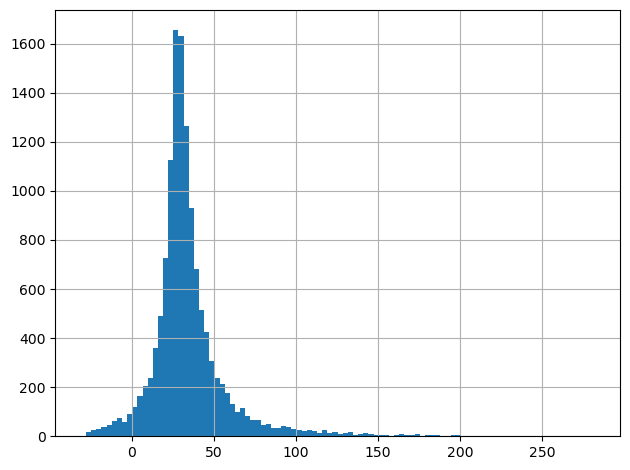

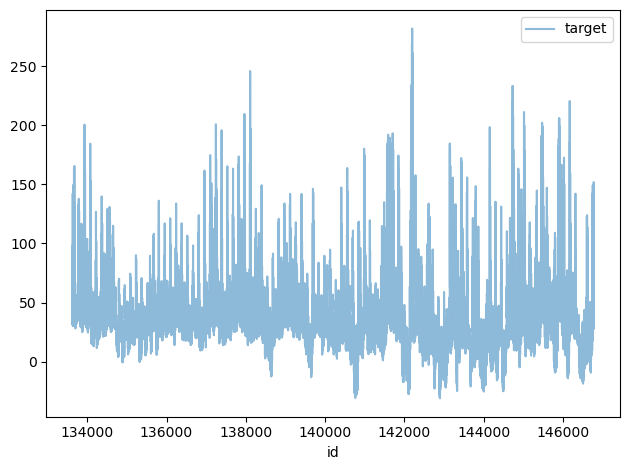

mean: 34.61029804574028
median: 30.36574515993805
std: 24.963141171726026
min: -30.993259218958496
max: 281.91504971290817


In [9]:
sub_quantile["target"].hist(bins=100)
plt.tight_layout()
plt.show()

sub_quantile.plot(x="id", y="target", alpha=0.5)
plt.tight_layout()
plt.show()


print(f"mean: {sub_quantile['target'].mean()}")
print(f"median: {sub_quantile['target'].median()}")
print(f"std: {sub_quantile['target'].std()}")
print(f"min: {sub_quantile['target'].min()}")
print(f"max: {sub_quantile['target'].max()}")



## Quantile models with tuned params (from outputs/final)

Uses best_params from Optuna-tuned XGB/LGB/CB (RMSE objective) per market. Same quantile training + stacking + submission flow, but with tuned hyperparameters instead of fixed defaults.

In [7]:
# Per-market quantile training with TUNED params from outputs/final
# Run per-market (point model) cell first. Loads best_params per market from outputs/final/{xgb,lgbm,catboost}_gap_168/
import json
from pathlib import Path

TUNED_PARAMS_DIR = Path("outputs/final")
XGB_PARAMS_PATH = TUNED_PARAMS_DIR / "xgb_gap_168"
LGB_PARAMS_PATH = TUNED_PARAMS_DIR / "lgbm_gap_168"
CB_PARAMS_PATH = TUNED_PARAMS_DIR / "catboost_gap_168"

q_models_xgb_tuned = {}
q_models_lgb_tuned = {}
q_models_cb_tuned = {}
q_combiners_tuned = {"xgb": {}, "lgb": {}, "cb": {}}

def _load_xgb_params(mkt):
    p = json.loads((XGB_PARAMS_PATH / mkt.replace(" ", "_") / "best_params.json").read_text())
    return {k: v for k, v in p.items() if k not in ("objective", "quantile_alpha", "quantile_alpha_tuned")}

def _load_lgb_params(mkt):
    p = json.loads((LGB_PARAMS_PATH / mkt.replace(" ", "_") / "best_params.json").read_text())
    return {k: v for k, v in p.items() if k not in ("objective", "alpha", "quantile_alpha_tuned", "random_state")}

def _load_cb_params(mkt):
    p = json.loads((CB_PARAMS_PATH / mkt.replace(" ", "_") / "best_params.json").read_text())
    return {k: v for k, v in p.items() if k not in ("loss_function", "quantile_alpha_tuned", "random_seed")}

def _combine_q_tuned(preds_by_alpha, alphas, weights, combiner=None):
    if combiner is not None:
        P = np.column_stack([preds_by_alpha[a] for a in alphas])
        return combiner.predict(P)
    return np.average([preds_by_alpha[a] for a in alphas], axis=0, weights=weights)

def _q_predict_xgb_tuned(mkt, a, X):
    return np.mean([m.predict(xgb.DMatrix(X)) for m in q_models_xgb_tuned[mkt][a]], axis=0)

def _q_predict_lgb_tuned(mkt, a, X):
    return np.mean([m.predict(X) for m in q_models_lgb_tuned[mkt][a]], axis=0)

def _q_predict_cb_tuned(mkt, a, X):
    return np.mean([m.predict(X) for m in q_models_cb_tuned[mkt][a]], axis=0)

print("Quantile per-market training with TUNED params (combine=ridge, seeds=SEEDS):")
for mkt in markets:
    tr = train_full[train_full["market"] == mkt].copy()
    va = val_full[val_full["market"] == mkt].copy()
    te = test_full[test_full["market"] == mkt].copy()
    tr = pd.concat([tr, va], ignore_index=True).sort_values("delivery_start").reset_index(drop=True)

    X_m = tr[feat_cols]
    y_m = tr["target"]
    n = len(X_m)
    cut = int(np.floor((1 - VAL_FRAC) * n))
    X_tr, y_tr = X_m.iloc[:cut], y_m.iloc[:cut]
    X_va, y_va = X_m.iloc[cut:], y_m.iloc[cut:]
    X_te = te[feat_cols]
    y_te = te["target"]

    if len(X_va) > EMBARGO:
        X_va = X_va.iloc[EMBARGO:].reset_index(drop=True)
        y_va = y_va.iloc[EMBARGO:].reset_index(drop=True)
    if len(X_te) > EMBARGO:
        X_te = X_te.iloc[EMBARGO:].reset_index(drop=True)
        y_te = y_te.iloc[EMBARGO:].reset_index(drop=True)

    q_models_xgb_tuned[mkt] = {}
    q_models_lgb_tuned[mkt] = {}
    q_models_cb_tuned[mkt] = {}
    preds_xgb_va, preds_lgb_va, preds_cb_va = {}, {}, {}
    preds_xgb_te, preds_lgb_te, preds_cb_te = {}, {}, {}

    try:
        xgb_bp = _load_xgb_params(mkt)
        lgb_bp = _load_lgb_params(mkt)
        cb_bp = _load_cb_params(mkt)
    except Exception as e:
        print(f"  {mkt}: Failed to load params: {e}. Skipping.")
        continue

    num_boost = int(xgb_bp.pop("num_boost_round", 3000))

    for a in QUANTILE_ALPHAS:
        _xgb_ms, _lgb_ms, _cb_ms = [], [], []
        _xgb_va_s, _lgb_va_s, _cb_va_s = [], [], []
        _xgb_te_s, _lgb_te_s, _cb_te_s = [], [], []
        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_va, label=y_va)
        dte = xgb.DMatrix(X_te)
        for seed in SEEDS:
            xgb_p = {"objective": "reg:quantileerror", "quantile_alpha": float(a), "tree_method": "hist", "seed": seed, **xgb_bp}
            bst = xgb.train(xgb_p, dtrain, num_boost_round=num_boost, evals=[(dval, "val")], early_stopping_rounds=150, verbose_eval=False)
            _xgb_ms.append(bst)
            _xgb_va_s.append(bst.predict(dval))
            _xgb_te_s.append(bst.predict(dte))

            lgb_p = {"objective": "quantile", "alpha": a, "random_state": seed, "n_jobs": -1, "verbosity": -1, **lgb_bp}
            lgb_m = lgb.LGBMRegressor(**lgb_p)
            lgb_m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(150, verbose=False)])
            _lgb_ms.append(lgb_m)
            _lgb_va_s.append(lgb_m.predict(X_va))
            _lgb_te_s.append(lgb_m.predict(X_te))

            cb_p = {"loss_function": f"Quantile:alpha={a}", "random_seed": seed, "verbose": 0, **cb_bp}
            cb_m = cb.CatBoostRegressor(**cb_p)
            cb_m.fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True, early_stopping_rounds=150)
            _cb_ms.append(cb_m)
            _cb_va_s.append(cb_m.predict(X_va))
            _cb_te_s.append(cb_m.predict(X_te))

        q_models_xgb_tuned[mkt][a] = _xgb_ms
        q_models_lgb_tuned[mkt][a] = _lgb_ms
        q_models_cb_tuned[mkt][a] = _cb_ms
        preds_xgb_va[a] = np.mean(_xgb_va_s, axis=0)
        preds_xgb_te[a] = np.mean(_xgb_te_s, axis=0)
        preds_lgb_va[a] = np.mean(_lgb_va_s, axis=0)
        preds_lgb_te[a] = np.mean(_lgb_te_s, axis=0)
        preds_cb_va[a] = np.mean(_cb_va_s, axis=0)
        preds_cb_te[a] = np.mean(_cb_te_s, axis=0)

    from sklearn.linear_model import Ridge as _Ridge
    for _key, _pva in [("xgb", preds_xgb_va), ("lgb", preds_lgb_va), ("cb", preds_cb_va)]:
        _P = np.column_stack([_pva[a] for a in QUANTILE_ALPHAS])
        _comb = _Ridge(alpha=1.0)
        _comb.fit(_P, y_va.values)
        q_combiners_tuned[_key][mkt] = _comb

    p_xgb_w = _combine_q_tuned(preds_xgb_te, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["xgb"].get(mkt))
    p_lgb_w = _combine_q_tuned(preds_lgb_te, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["lgb"].get(mkt))
    p_cb_w = _combine_q_tuned(preds_cb_te, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["cb"].get(mkt))
    y_arr = y_te.values
    r_x, r_l, r_c = _rmse(y_arr, p_xgb_w), _rmse(y_arr, p_lgb_w), _rmse(y_arr, p_cb_w)
    r_ens = _rmse(y_arr, (p_xgb_w + p_lgb_w + p_cb_w) / 3)
    print(f"  {mkt}: xgb_q={r_x:.2f}  lgb_q={r_l:.2f}  cb_q={r_c:.2f}  ens={r_ens:.2f}")

print("\nQuantile per-market training (tuned params) done.")

Quantile per-market training with TUNED params (combine=ridge, seeds=SEEDS):


KeyboardInterrupt: 

In [ ]:
# Quantile stacking (tuned): Ridge + MLP on weighted-average quantile predictions per market
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

print("Quantile stacking (tuned): per-market RMSE (avg | ridge | mlp | best)")
q_stack_results_tuned = []
q_models_ridge_tuned, q_models_mlp_tuned = {}, {}
q_all_p_ridge, q_all_p_mlp, q_all_p_avg, q_all_p_best, q_all_y_te = [], [], [], [], []

for mkt in markets:
    if mkt not in q_models_xgb_tuned:
        continue
    tr = train_full[train_full["market"] == mkt].copy()
    va = val_full[val_full["market"] == mkt].copy()
    te = test_full[test_full["market"] == mkt].copy()
    tr = pd.concat([tr, va], ignore_index=True).sort_values("delivery_start").reset_index(drop=True)
    n = len(tr)
    cut = int(np.floor((1 - VAL_FRAC) * n))
    X_va = tr.iloc[cut:][feat_cols]
    y_va = tr.iloc[cut:]["target"]
    X_te = te[feat_cols]
    y_te = te["target"]
    if len(X_va) > EMBARGO:
        X_va = X_va.iloc[EMBARGO:].reset_index(drop=True)
        y_va = y_va.iloc[EMBARGO:].reset_index(drop=True)
    if len(X_te) > EMBARGO:
        X_te = X_te.iloc[EMBARGO:].reset_index(drop=True)
        y_te = y_te.iloc[EMBARGO:].reset_index(drop=True)

    _pxv = {a: _q_predict_xgb_tuned(mkt, a, X_va) for a in QUANTILE_ALPHAS}
    _plv = {a: _q_predict_lgb_tuned(mkt, a, X_va) for a in QUANTILE_ALPHAS}
    _pcv = {a: _q_predict_cb_tuned(mkt, a, X_va) for a in QUANTILE_ALPHAS}
    _pxt = {a: _q_predict_xgb_tuned(mkt, a, X_te) for a in QUANTILE_ALPHAS}
    _plt = {a: _q_predict_lgb_tuned(mkt, a, X_te) for a in QUANTILE_ALPHAS}
    _pct = {a: _q_predict_cb_tuned(mkt, a, X_te) for a in QUANTILE_ALPHAS}

    p_xgb_va = _combine_q_tuned(_pxv, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["xgb"].get(mkt))
    p_lgb_va = _combine_q_tuned(_plv, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["lgb"].get(mkt))
    p_cb_va = _combine_q_tuned(_pcv, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["cb"].get(mkt))
    p_xgb_te = _combine_q_tuned(_pxt, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["xgb"].get(mkt))
    p_lgb_te = _combine_q_tuned(_plt, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["lgb"].get(mkt))
    p_cb_te = _combine_q_tuned(_pct, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["cb"].get(mkt))

    P_va = np.column_stack([p_xgb_va, p_lgb_va, p_cb_va])
    P_te = np.column_stack([p_xgb_te, p_lgb_te, p_cb_te])

    p_avg_te = (p_xgb_te + p_lgb_te + p_cb_te) / 3
    rmse_avg = _rmse(y_te, p_avg_te)
    q_all_p_avg.append(p_avg_te)

    ridge = Ridge(alpha=1.0).fit(P_va, y_va)
    q_models_ridge_tuned[mkt] = ridge
    p_ridge_te = ridge.predict(P_te)
    rmse_ridge = _rmse(y_te, p_ridge_te)
    q_all_p_ridge.append(p_ridge_te)
    q_all_y_te.append(y_te.values)

    mlp = MLPRegressor(hidden_layer_sizes=(32, 16), alpha=0.1, max_iter=500, early_stopping=True, random_state=42)
    mlp.fit(P_va, y_va)
    q_models_mlp_tuned[mkt] = mlp
    p_mlp_te = mlp.predict(P_te)
    rmse_mlp = _rmse(y_te, p_mlp_te)
    q_all_p_mlp.append(p_mlp_te)

    best = min([("avg", rmse_avg), ("ridge", rmse_ridge), ("mlp", rmse_mlp)], key=lambda x: x[1])[0]
    p_best_te = p_ridge_te if best == "ridge" else (p_mlp_te if best == "mlp" else p_avg_te)
    q_all_p_best.append(p_best_te)
    q_stack_results_tuned.append({"market": mkt, "rmse_avg": rmse_avg, "rmse_ridge": rmse_ridge, "rmse_mlp": rmse_mlp, "best": best})
    print(f"  {mkt}: avg={rmse_avg:.2f}  ridge={rmse_ridge:.2f}  mlp={rmse_mlp:.2f}  best={best}")

y_q_all = np.concatenate(q_all_y_te)
print(f"\nOverall quantile (tuned) test RMSE:")
print(f"  Simple avg:       {_rmse(y_q_all, np.concatenate(q_all_p_avg)):.2f}")
print(f"  Ridge stack:      {_rmse(y_q_all, np.concatenate(q_all_p_ridge)):.2f}")
print(f"  MLP stack:        {_rmse(y_q_all, np.concatenate(q_all_p_mlp)):.2f}")
print(f"  Best-per-market:  {_rmse(y_q_all, np.concatenate(q_all_p_best)):.2f}")

In [ ]:
# Predict on real test using best quantile stacking method per market (tuned models). Run quantile stacking (tuned) cell first.
# Saves submission to submissions/submission_quantile_tuned_stack.csv
q_best_per_market_tuned = {r["market"]: r["best"] for r in q_stack_results_tuned}
q_real_preds_tuned = []
markets_in_test = sorted(test_pred_full["market"].unique())
for mkt in markets_in_test:
    if mkt not in q_best_per_market_tuned:
        print(f"Warning: no quantile tuned model for market '{mkt}', skipping")
        continue
    mask = test_pred_full["market"] == mkt
    if mask.sum() == 0:
        continue
    X_real = test_pred_full.loc[mask, feat_cols]
    ids_m = test_pred_full.loc[mask, "id"].values

    _px = {a: _q_predict_xgb_tuned(mkt, a, X_real) for a in QUANTILE_ALPHAS}
    _pl = {a: _q_predict_lgb_tuned(mkt, a, X_real) for a in QUANTILE_ALPHAS}
    _pc = {a: _q_predict_cb_tuned(mkt, a, X_real) for a in QUANTILE_ALPHAS}
    p_xgb = _combine_q_tuned(_px, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["xgb"].get(mkt))
    p_lgb = _combine_q_tuned(_pl, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["lgb"].get(mkt))
    p_cb = _combine_q_tuned(_pc, QUANTILE_ALPHAS, QUANTILE_WEIGHTS, q_combiners_tuned["cb"].get(mkt))
    P_real = np.column_stack([p_xgb, p_lgb, p_cb])
    p_avg = (p_xgb + p_lgb + p_cb) / 3
    p_ridge = q_models_ridge_tuned[mkt].predict(P_real)
    p_mlp = q_models_mlp_tuned[mkt].predict(P_real)
    best = q_best_per_market_tuned[mkt]
    p_final = p_ridge if best == "ridge" else (p_mlp if best == "mlp" else p_avg)
    q_real_preds_tuned.append(pd.DataFrame({"id": ids_m, "target": p_final}))

sub_quantile_tuned = pd.concat(q_real_preds_tuned, ignore_index=True).sort_values("id").reset_index(drop=True)
os.makedirs("submissions", exist_ok=True)
sub_quantile_tuned.to_csv("submissions/submission_quantile_tuned_stack.csv", index=False)
print(f"Quantile tuned stack submission saved: {len(sub_quantile_tuned)} rows -> submissions/submission_quantile_tuned_stack.csv")
print(f"Per-market choices: {q_best_per_market_tuned}")

In [13]:
tmp1 = pd.read_csv("submissions/submission_quantile_stack_ridge_2.csv")
tmp2 = pd.read_csv("submissions/submission_best_per_market_stack_6.csv")
tmp3 = pd.read_csv("submissions/submission_mlp_stack_2.csv")
tmp4 = tmp1.copy()
tmp4["target"] = (0.55*tmp1["target"] + 0.15*tmp2["target"] + 0.3*tmp3["target"])
tmp1.to_csv("submissions/submission_final_stack.csv", index=False)


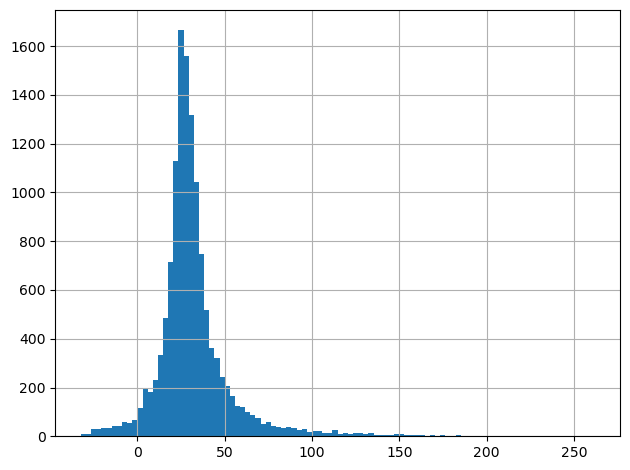

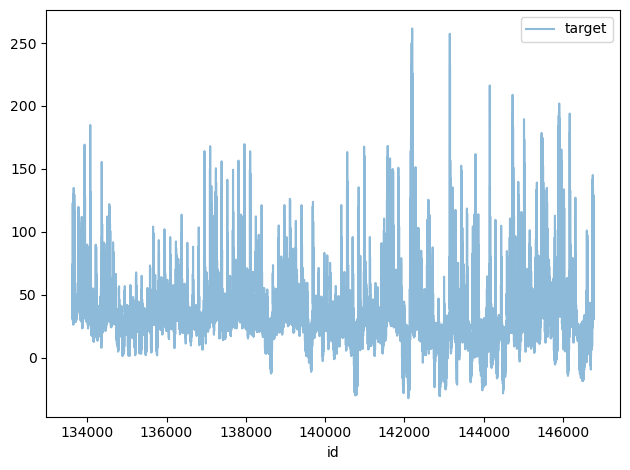

mean: 32.27801477584518
median: 28.507164235107762
std: 23.031041703898097
min: -32.217806696337625
max: 261.5613956467981


In [14]:
tmp4["target"].hist(bins=100)
plt.tight_layout()
plt.show()

tmp4.plot(x="id", y="target", alpha=0.5)
plt.tight_layout()
plt.show()


print(f"mean: {tmp4['target'].mean()}")
print(f"median: {tmp4['target'].median()}")
print(f"std: {tmp4['target'].std()}")
print(f"min: {tmp4['target'].min()}")
print(f"max: {tmp4['target'].max()}")

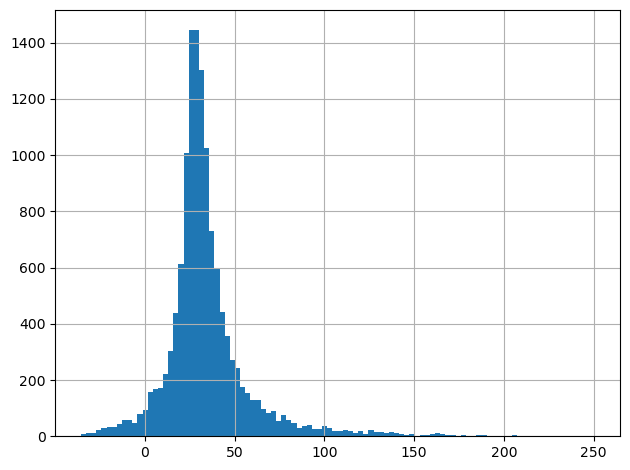

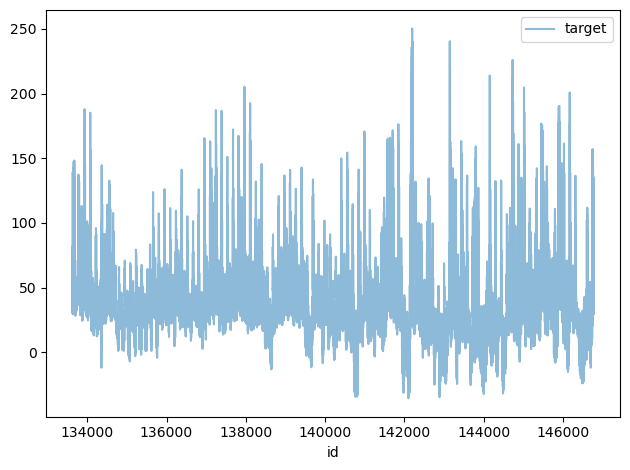

mean: 34.35209480014428
median: 30.26499431255144
std: 24.79674179093541
min: -35.59182559609643
max: 250.3194064224556


In [12]:
tmp1["target"].hist(bins=100)
plt.tight_layout()
plt.show()

tmp1.plot(x="id", y="target", alpha=0.5)
plt.tight_layout()
plt.show()


print(f"mean: {tmp1['target'].mean()}")
print(f"median: {tmp1['target'].median()}")
print(f"std: {tmp1['target'].std()}")
print(f"min: {tmp1['target'].min()}")
print(f"max: {tmp1['target'].max()}")